# PARETO-RKD for mRI Rehabilitation-Exercise Recognition

## Pareto-Safe Adaptive Reliability, Calibration and Corruption-Robust Knowledge Distillation

This notebook is a second-generation methodology designed specifically to address the four weaknesses observed in RTPD-Net:

1. **Insufficiently adaptive reliability gate**
2. **Weak radar-student calibration**
3. **Large degradation under radar corruption**
4. **Auxiliary distillation losses underperforming standard logit KD**

### Proposed contributions

- **Counterfactual Reliability Supervision (CRS):** modality weights are supervised using the relative true-class losses of the radar and IMU experts.
- **Directional Gate Ranking (DGR):** IMU corruption must increase radar weight, and radar corruption must increase IMU weight.
- **Worst-View Radar Curriculum (WVRC):** the student is trained against the most difficult of multiple radar corruptions at each step.
- **Instance-Temperature Calibration (ITC):** the radar student predicts a bounded sample-dependent temperature and is trained with NLL, Brier and entropy-matching terms.
- **Gradient-Aligned Auxiliary Routing (GAAR):** temporal, relation and prototype losses are used only when their gradients agree with the primary CE+KD objective.
- **Loss-Scale Normalisation (LSN):** each auxiliary loss is normalised by an exponential moving average so no large-magnitude loss dominates.
- **Pareto-Safe Checkpoint Fusion (PSCF):** standard KD and the enhanced student are interpolated using validation data only; the selected model must satisfy clean-performance, robustness and calibration safeguards.

The final deployment system remains **radar-only**.

## Scientific-use note

The method is designed to improve all targeted dimensions, but no architecture can guarantee higher unseen-test performance before it is trained and evaluated. This notebook therefore includes a **validation safeguard**: when the enhanced model does not meet the Pareto criteria, the final deployment checkpoint automatically falls back to standard KD or to a validation-selected interpolation between the two.

The test set is never used for checkpoint selection, calibration fitting, loss weighting or interpolation.

In [42]:
from dataclasses import dataclass, asdict
from pathlib import Path

@dataclass
class CFG:
    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------
    DATA_ROOT: str | None = None
    WORK_DIR: str = "/kaggle/working/pareto_rkd_mri"
    PROTOCOL: str = "P2_10"
    SEQ_LEN: int = 96
    MIN_SEGMENT_FRACTION: float = 0.001
    NUMERIC_LABEL_MODE: str = "auto"
    EXTRA_BACKGROUND_NUMERIC_IDS: tuple = (-1,)
    MIN_TOTAL_MANIFEST_SEGMENTS: int = 50
    MIN_SUBJECTS_PER_CLASS: int = 3
    MAX_SEGMENTS_PER_CLASS_PER_SUBJECT: int | None = None

    # --------------------------------------------------------
    # Subject-independent split
    # --------------------------------------------------------
    TEST_SUBJECT_FRACTION: float = 0.20
    VAL_SUBJECT_FRACTION_OF_REMAINDER: float = 0.25
    SPLIT_SEED: int = 2026
    SPLIT_SEARCH_ATTEMPTS: int = 50000

    # --------------------------------------------------------
    # Loader
    # --------------------------------------------------------
    BATCH_SIZE: int = 20
    NUM_WORKERS: int = 2
    CACHE_SUBJECTS_PER_WORKER: int = 3
    USE_WEIGHTED_SAMPLER: bool = False
    STAT_MAX_FRAMES_PER_SUBJECT: int = 4000

    # --------------------------------------------------------
    # Architecture
    # --------------------------------------------------------
    EMBED_DIM: int = 128
    TCN_CHANNELS: tuple = (128, 128, 128, 128)
    TCN_DILATIONS: tuple = (1, 2, 4, 8)
    DROPOUT: float = 0.22
    NUM_ATTENTION_HEADS: int = 4
    PROJECTION_DIM: int = 96

    # Instance-temperature range
    MIN_INSTANCE_TEMPERATURE: float = 0.55
    MAX_INSTANCE_TEMPERATURE: float = 3.00

    # --------------------------------------------------------
    # Optimisation
    # --------------------------------------------------------
    LEARNING_RATE: float = 3e-4
    SSL_LEARNING_RATE: float = 4e-4
    WEIGHT_DECAY: float = 1e-4
    PATIENCE: int = 6
    GRAD_CLIP: float = 5.0
    LABEL_SMOOTHING: float = 0.03
    AMP: bool = True

    # --------------------------------------------------------
    # Training stages
    # --------------------------------------------------------
    RUN_SSL: bool = True
    SSL_EPOCHS: int = 10
    BASELINE_EPOCHS: int = 16
    TEACHER_EPOCHS: int = 22
    ANCHOR_EPOCHS: int = 22
    ENHANCED_EPOCHS: int = 26

    # --------------------------------------------------------
    # SSL
    # --------------------------------------------------------
    SSL_MASK_PROB: float = 0.30
    SSL_CONTRASTIVE_TEMP: float = 0.15
    SSL_RECON_WEIGHT: float = 1.0
    SSL_CONTRASTIVE_WEIGHT: float = 0.35

    # --------------------------------------------------------
    # Counterfactual reliability teacher
    # --------------------------------------------------------
    GATE_TARGET_TEMPERATURE: float = 0.55
    GATE_SUPERVISION_WEIGHT: float = 0.85
    GATE_RANK_WEIGHT: float = 0.45
    GATE_DIVERSITY_WEIGHT: float = 0.03
    TEACHER_EXPERT_WEIGHT: float = 0.25
    TEACHER_CORRUPT_WEIGHT: float = 0.60
    TEACHER_CONSISTENCY_WEIGHT: float = 0.12
    GATE_RANK_MARGIN: float = 0.08
    MIN_GATE_BATCH_STD: float = 0.035

    # --------------------------------------------------------
    # Standard and adaptive KD
    # --------------------------------------------------------
    KD_TEMPERATURE: float = 4.0
    STANDARD_KD_WEIGHT: float = 0.90
    ADAPTIVE_KD_MIN: float = 0.10
    ADAPTIVE_KD_MAX: float = 1.10

    # --------------------------------------------------------
    # Radar robustness
    # --------------------------------------------------------
    ROBUST_CE_WEIGHT: float = 0.65
    ROBUST_KD_WEIGHT: float = 0.25
    CONSISTENCY_WEIGHT: float = 0.18
    CORRUPTION_MIN_SEVERITY: float = 0.08
    CORRUPTION_MAX_SEVERITY: float = 0.55
    ROBUST_WARMUP_FRACTION: float = 0.30

    # --------------------------------------------------------
    # Calibration
    # --------------------------------------------------------
    BRIER_WEIGHT: float = 0.18
    ENTROPY_MATCH_WEIGHT: float = 0.08
    TEMPERATURE_REG_WEIGHT: float = 0.015
    CALIBRATION_BINS: int = 10
    CONFORMAL_ALPHA: float = 0.10

    # --------------------------------------------------------
    # Gradient-aligned auxiliary routing
    # Lower base weights than RTPD-Net; actual weights are gated.
    # --------------------------------------------------------
    TEMPORAL_BASE_WEIGHT: float = 0.14
    RELATION_BASE_WEIGHT: float = 0.07
    PROTOTYPE_BASE_WEIGHT: float = 0.12
    AUX_EMA_DECAY: float = 0.95
    AUX_ALIGNMENT_POWER: float = 2.0
    TEMPORAL_ALIGNMENT_TEMP: float = 0.12
    PROTOTYPE_TEMP: float = 0.15

    # --------------------------------------------------------
    # Pareto-safe selection
    # --------------------------------------------------------
    SOUP_GRID: tuple = tuple(i / 10 for i in range(11))
    CLEAN_F1_TOLERANCE: float = 0.005
    ROBUST_F1_TOLERANCE: float = 0.005
    ECE_TOLERANCE: float = 0.010
    NLL_TOLERANCE: float = 0.050

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------
    BOOTSTRAP_SAMPLES: int = 1000
    RUN_ROBUSTNESS: bool = True
    RUN_ABLATIONS: bool = True
    ABLATION_EPOCHS: int = 18
    RUN_GROUPED_CV: bool = True
    CV_EPOCHS: int = 8
    CV_FOLDS: int = 5

    # --------------------------------------------------------
    # Runtime
    # --------------------------------------------------------
    REQUIRE_GPU: bool = True
    QUICK_RUN: bool = False
    SEED: int = 2026

cfg = CFG()

if cfg.QUICK_RUN:
    cfg.SSL_EPOCHS = 2
    cfg.BASELINE_EPOCHS = 2
    cfg.TEACHER_EPOCHS = 2
    cfg.ANCHOR_EPOCHS = 2
    cfg.ENHANCED_EPOCHS = 2
    cfg.ABLATION_EPOCHS = 2
    cfg.CV_EPOCHS = 2
    cfg.BOOTSTRAP_SAMPLES = 200

Path(cfg.WORK_DIR).mkdir(parents=True, exist_ok=True)
print(asdict(cfg))

{'DATA_ROOT': None, 'WORK_DIR': '/kaggle/working/pareto_rkd_mri', 'PROTOCOL': 'P2_10', 'SEQ_LEN': 96, 'MIN_SEGMENT_FRACTION': 0.001, 'NUMERIC_LABEL_MODE': 'auto', 'EXTRA_BACKGROUND_NUMERIC_IDS': (-1,), 'MIN_TOTAL_MANIFEST_SEGMENTS': 50, 'MIN_SUBJECTS_PER_CLASS': 3, 'MAX_SEGMENTS_PER_CLASS_PER_SUBJECT': None, 'TEST_SUBJECT_FRACTION': 0.2, 'VAL_SUBJECT_FRACTION_OF_REMAINDER': 0.25, 'SPLIT_SEED': 2026, 'SPLIT_SEARCH_ATTEMPTS': 50000, 'BATCH_SIZE': 20, 'NUM_WORKERS': 2, 'CACHE_SUBJECTS_PER_WORKER': 3, 'USE_WEIGHTED_SAMPLER': False, 'STAT_MAX_FRAMES_PER_SUBJECT': 4000, 'EMBED_DIM': 128, 'TCN_CHANNELS': (128, 128, 128, 128), 'TCN_DILATIONS': (1, 2, 4, 8), 'DROPOUT': 0.22, 'NUM_ATTENTION_HEADS': 4, 'PROJECTION_DIM': 96, 'MIN_INSTANCE_TEMPERATURE': 0.55, 'MAX_INSTANCE_TEMPERATURE': 3.0, 'LEARNING_RATE': 0.0003, 'SSL_LEARNING_RATE': 0.0004, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 6, 'GRAD_CLIP': 5.0, 'LABEL_SMOOTHING': 0.03, 'AMP': True, 'RUN_SSL': True, 'SSL_EPOCHS': 10, 'BASELINE_EPOCHS': 16, 'TE

In [43]:
# ============================================================
# Imports and automatic Tesla P100-compatible PyTorch setup
# ============================================================

import os
import gc
import re
import json
import copy
import math
import pickle
import random
import shutil
import warnings
import signal
import subprocess
import sys
import time

from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from sklearn.model_selection import GroupShuffleSplit


# ------------------------------------------------------------
# Import PyTorch before using any CUDA operation
# ------------------------------------------------------------

import torch


# ------------------------------------------------------------
# P100 compatibility configuration
# ------------------------------------------------------------

P100_TORCH_VERSION = "2.8.0"
P100_TORCHVISION_VERSION = "0.23.0"
P100_TORCHAUDIO_VERSION = "2.8.0"

P100_WHEEL_INDEX = (
    "https://download.pytorch.org/whl/cu126"
)

INSTALL_MARKER = Path(
    "/kaggle/working/.rtpd_p100_cu126_install_attempted"
)


def install_p100_compatible_pytorch():
    """
    Replace the incompatible CUDA 12.8 PyTorch build with the
    official CUDA 12.6 build containing sm_60 support.

    A complete kernel restart is mandatory after installation.
    """

    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--no-cache-dir",
        f"torch=={P100_TORCH_VERSION}",
        f"torchvision=={P100_TORCHVISION_VERSION}",
        f"torchaudio=={P100_TORCHAUDIO_VERSION}",
        "--index-url",
        P100_WHEEL_INDEX,
    ]

    print("\n" + "=" * 80)
    print("INSTALLING TESLA P100-COMPATIBLE PYTORCH")
    print("=" * 80)

    print(
        "\nCurrent PyTorch build does not contain "
        "the sm_60 kernels required by the Tesla P100."
    )

    print("\nInstallation command:")
    print(" ".join(command))

    print(
        "\nThis can take several minutes because the CUDA-enabled "
        "PyTorch packages are large."
    )

    completed = subprocess.run(
        command,
        stdout=None,
        stderr=None,
        check=False,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "The P100-compatible PyTorch installation failed.\n\n"
            "Check the following:\n"
            "1. Kaggle Internet is enabled.\n"
            "2. The notebook session has enough available disk space.\n"
            "3. Restart the Kaggle session before trying again."
        )

    INSTALL_MARKER.write_text(
        json.dumps({
            "installed_at": time.time(),
            "torch": P100_TORCH_VERSION,
            "torchvision": P100_TORCHVISION_VERSION,
            "torchaudio": P100_TORCHAUDIO_VERSION,
            "cuda": "12.6",
        }),
        encoding="utf-8",
    )

    print("\nInstallation completed successfully.")
    print(
        "The current Python process still has the previous PyTorch "
        "libraries loaded, so it must restart now."
    )
    print(
        "\nAfter Kaggle reconnects, select Run All or rerun the "
        "notebook from the first cell."
    )

    # Flush output before terminating the current Python process.
    sys.stdout.flush()
    sys.stderr.flush()

    # A hard process restart is required after replacing torch.
    os.kill(
        os.getpid(),
        signal.SIGKILL,
    )


def inspect_cuda_compatibility():
    """
    Return details about the attached GPU and PyTorch build without
    launching a CUDA computation kernel.
    """

    information = {
        "cuda_available": torch.cuda.is_available(),
        "torch_version": torch.__version__,
        "torch_cuda_version": torch.version.cuda,
        "gpu_name": None,
        "gpu_capability": None,
        "required_architecture": None,
        "compiled_architectures": [],
        "architecture_supported": False,
    }

    if not information["cuda_available"]:
        return information

    information["gpu_name"] = (
        torch.cuda.get_device_name(0)
    )

    information["gpu_capability"] = (
        torch.cuda.get_device_capability(0)
    )

    major, minor = information["gpu_capability"]

    information["required_architecture"] = (
        f"sm_{major}{minor}"
    )

    try:
        information["compiled_architectures"] = (
            torch.cuda.get_arch_list()
        )
    except Exception:
        information["compiled_architectures"] = []

    information["architecture_supported"] = (
        information["required_architecture"]
        in information["compiled_architectures"]
    )

    return information


# ------------------------------------------------------------
# Inspect before creating any CUDA tensors
# ------------------------------------------------------------

cuda_information = inspect_cuda_compatibility()

print("Current PyTorch:", cuda_information["torch_version"])
print(
    "Current PyTorch CUDA build:",
    cuda_information["torch_cuda_version"],
)
print(
    "CUDA available:",
    cuda_information["cuda_available"],
)


if not cuda_information["cuda_available"]:
    raise RuntimeError(
        "CUDA is not currently available.\n\n"
        "In Kaggle:\n"
        "1. Open Notebook Settings.\n"
        "2. Select GPU as the accelerator.\n"
        "3. Save the setting.\n"
        "4. Restart the session.\n"
        "5. Run the notebook again."
    )


print(
    "Detected GPU:",
    cuda_information["gpu_name"],
)

print(
    "GPU capability:",
    cuda_information["gpu_capability"],
)

print(
    "Required architecture:",
    cuda_information["required_architecture"],
)

print(
    "Architectures compiled into PyTorch:",
    cuda_information["compiled_architectures"],
)


# ------------------------------------------------------------
# Install a compatible build before launching any CUDA kernel
# ------------------------------------------------------------

if not cuda_information["architecture_supported"]:

    if INSTALL_MARKER.exists():
        marker_information = INSTALL_MARKER.read_text(
            encoding="utf-8"
        )

        raise RuntimeError(
            "A P100-compatible PyTorch installation was already attempted, "
            "but the current Python process is still using the incompatible "
            "build.\n\n"
            "Restart the complete Kaggle session, not only the current cell, "
            "and then run the notebook from the beginning.\n\n"
            f"Install marker: {marker_information}"
        )

    install_p100_compatible_pytorch()


# The marker is no longer needed once a compatible build is active.
INSTALL_MARKER.unlink(
    missing_ok=True
)


# ------------------------------------------------------------
# Import PyTorch modules after compatibility is confirmed
# ------------------------------------------------------------

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)


warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=2026):
    random.seed(seed)
    np.random.seed(seed)

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything(
    cfg.SEED
)


# ------------------------------------------------------------
# GPU-only device selection
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda:0"
)

torch.cuda.set_device(0)


if cfg.REQUIRE_GPU and DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required because "
        "cfg.REQUIRE_GPU=True."
    )


# ------------------------------------------------------------
# Real P100 CUDA kernel test
# ------------------------------------------------------------

print("\nRunning CUDA convolution smoke test...")

try:
    probe = torch.randn(
        2,
        5,
        14,
        14,
        device=DEVICE,
    )

    probe_layer = nn.Conv2d(
        in_channels=5,
        out_channels=8,
        kernel_size=3,
        padding=1,
    ).to(DEVICE)

    with torch.inference_mode():
        probe_output = probe_layer(
            probe
        )

    # Force asynchronous CUDA errors to be raised here.
    torch.cuda.synchronize()

except Exception as error:
    raise RuntimeError(
        "The installed PyTorch build reports support for the P100, "
        "but the CUDA convolution test failed.\n\n"
        "Restart the complete Kaggle session and rerun the notebook "
        "from the beginning."
    ) from error


print(
    "CUDA convolution test output:",
    tuple(probe_output.shape),
)


del (
    probe,
    probe_layer,
    probe_output,
)

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final environment summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TESLA P100 ENVIRONMENT READY")
print("=" * 80)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "PyTorch CUDA build:",
    torch.version.cuda,
)

print(
    "Selected device:",
    DEVICE,
)

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Capability:",
    torch.cuda.get_device_capability(0),
)

print(
    "Compiled CUDA architectures:",
    torch.cuda.get_arch_list(),
)

print(
    "Allocated GPU memory:",
    round(
        torch.cuda.memory_allocated(0)
        / 1024**2,
        2,
    ),
    "MB",
)

print(
    "\nTesla P100 CUDA convolution smoke test passed."
)

Current PyTorch: 2.8.0+cu126
Current PyTorch CUDA build: 12.6
CUDA available: True
Detected GPU: Tesla P100-PCIE-16GB
GPU capability: (6, 0)
Required architecture: sm_60
Architectures compiled into PyTorch: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']

Running CUDA convolution smoke test...
CUDA convolution test output: (2, 8, 14, 14)

TESLA P100 ENVIRONMENT READY
PyTorch: 2.8.0+cu126
PyTorch CUDA build: 12.6
Selected device: cuda:0
GPU: Tesla P100-PCIE-16GB
Capability: (6, 0)
Compiled CUDA architectures: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Allocated GPU memory: 69.43 MB

Tesla P100 CUDA convolution smoke test passed.


In [3]:
from pathlib import Path

def looks_like_mri_root(path: Path) -> bool:
    return (
        path.exists()
        and path.is_dir()
        and (path / "features" / "radar").exists()
        and (path / "features" / "imu").exists()
        and (path / "aligned_data").exists()
        and (path / "raw_data").exists()
    )

def discover_mri_root(search_roots=None) -> Path | None:
    if cfg.DATA_ROOT is not None:
        configured = Path(cfg.DATA_ROOT)
        if looks_like_mri_root(configured):
            print("Using configured DATA_ROOT:", configured)
            return configured
        raise FileNotFoundError(
            f"Configured DATA_ROOT is not valid: {configured}\n"
            "It must directly contain features/, aligned_data/, and raw_data/."
        )

    exact_candidates = [
        Path("/kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release"),
        Path("/kaggle/input/dataset-mri/dataset_release"),
        Path("/kaggle/input/dataset-mri"),
    ]

    for candidate in exact_candidates:
        if looks_like_mri_root(candidate):
            print("Found mRI root:", candidate)
            return candidate

    search_roots = search_roots or [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
    ]

    for base in search_roots:
        if not base.exists():
            continue
        for features_dir in base.rglob("features"):
            candidate = features_dir.parent
            if looks_like_mri_root(candidate):
                print("Automatically discovered mRI root:", candidate)
                return candidate

    return None

DATA_ROOT = discover_mri_root()

if DATA_ROOT is None:
    print("Could not locate the mRI root. Shallow Kaggle input tree:")
    base = Path("/kaggle/input")
    if base.exists():
        for path in sorted(base.rglob("*")):
            try:
                rel = path.relative_to(base)
                if len(rel.parts) <= 5:
                    print("  " * (len(rel.parts) - 1) + rel.name + ("/" if path.is_dir() else ""))
            except Exception:
                pass

    raise FileNotFoundError(
        "The extracted mRI dataset could not be located. "
        "Set cfg.DATA_ROOT to the directory that directly contains "
        "aligned_data/, features/, model/, and raw_data/."
    )

RADAR_DIR = DATA_ROOT / "features" / "radar"
IMU_DIR = DATA_ROOT / "features" / "imu"
POSE_LABEL_DIR = DATA_ROOT / "aligned_data" / "pose_labels"
RAW_VIDEO_LABEL_DIR = DATA_ROOT / "raw_data" / "videolabels"

print("\nDataset root:", DATA_ROOT)
print("Radar features:", RADAR_DIR)
print("IMU features:", IMU_DIR)
print("Pose labels:", POSE_LABEL_DIR)
print("Raw video labels:", RAW_VIDEO_LABEL_DIR)

Found mRI root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release

Dataset root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release
Radar features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar
IMU features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu
Pose labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels
Raw video labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/raw_data/videolabels


In [4]:
P1_CLASS_NAMES = [
    "left upper-limb extension",
    "right upper-limb extension",
    "both upper-limb extension",
    "left front lunge",
    "right front lunge",
    "squat",
    "left side lunge",
    "right side lunge",
    "left limb extension",
    "right limb extension",
    "free-form stretching/relaxing",
    "walking",
]
P2_CLASS_NAMES = P1_CLASS_NAMES[:10]
CLASS_NAMES = P2_CLASS_NAMES if cfg.PROTOCOL == "P2_10" else P1_CLASS_NAMES
NUM_CLASSES = len(CLASS_NAMES)

def normalise_text(x):
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

ALIASES = {
    "left upper limb extension": 0,
    "left upper limbs extension": 0,
    "right upper limb extension": 1,
    "right upper limbs extension": 1,
    "both upper limb extension": 2,
    "both upper limbs extension": 2,
    "left front lunge": 3,
    "left front lung": 3,
    "right front lunge": 4,
    "right front lung": 4,
    "squat": 5,
    "left side lunge": 6,
    "left side lung": 6,
    "right side lunge": 7,
    "right side lung": 7,
    "left limb extension": 8,
    "left lower limb extension": 8,
    "right limb extension": 9,
    "right lower limb extension": 9,
    "free form stretching relaxing": 10,
    "free form stretch relax": 10,
    "stretching relaxing": 10,
    "relaxing stretching": 10,
    "walking": 11,
    "walk": 11,
}
BACKGROUND_ALIASES = {
    "", "none", "nan", "background", "bg", "transition", "idle",
    "t pose", "tpose", "calibration", "unknown", "other"
}

print(f"Protocol: {cfg.PROTOCOL} | classes: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:02d}: {name}")

Protocol: P2_10 | classes: 10
00: left upper-limb extension
01: right upper-limb extension
02: both upper-limb extension
03: left front lunge
04: right front lunge
05: squat
06: left side lunge
07: right side lunge
08: left limb extension
09: right limb extension


In [5]:
def safe_pickle_load(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)

def load_any(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".npy":
        return np.load(path, mmap_mode="r")
    if suffix in {".pt", ".pth"}:
        return torch.load(path, map_location="cpu", weights_only=False)
    if suffix in {".cpl", ".pkl", ".pickle"}:
        return safe_pickle_load(path)
    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            return json.load(handle)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".txt", ".tsv"}:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return path.read_text(errors="ignore")

    raise ValueError(f"Unsupported file: {path}")

def summarise_object(obj, depth=0, max_depth=3):
    indent = "  " * depth
    if depth > max_depth:
        return f"{indent}..."

    if isinstance(obj, dict):
        lines = [f"{indent}dict(keys={list(obj.keys())[:30]})"]
        for key, value in list(obj.items())[:8]:
            lines.append(
                f"{indent}- {key!r}: "
                f"{summarise_object(value, depth + 1, max_depth)}"
            )
        return "\n".join(lines)

    if isinstance(obj, pd.DataFrame):
        return f"{indent}DataFrame(shape={obj.shape}, columns={list(obj.columns)})"

    if torch.is_tensor(obj):
        preview = obj.reshape(-1)[:5].detach().cpu().tolist() if obj.numel() else []
        return (
            f"{indent}Tensor(shape={tuple(obj.shape)}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, np.ndarray):
        preview = obj.reshape(-1)[:5].tolist() if obj.size else []
        return (
            f"{indent}ndarray(shape={obj.shape}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, (list, tuple)):
        first = summarise_object(obj[0], depth + 1, max_depth) if obj else "empty"
        return f"{indent}{type(obj).__name__}(len={len(obj)}, first=\n{first})"

    return f"{indent}{type(obj).__name__}: {str(obj)[:300]}"

def extract_subject_id(path) -> str:
    text = str(path).lower()

    patterns = [
        r"subject[\s_\-]*0*(\d+)",
        r"subj(?:ect)?[\s_\-]*0*(\d+)",
        r"participant[\s_\-]*0*(\d+)",
        r"(?:^|[/_\-])s0*(\d+)(?:[/_\-.]|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return f"subject{int(match.group(1)):02d}"

    numbers = re.findall(r"(?<!\d)(\d{1,2})(?!\d)", Path(path).stem)
    if numbers:
        return f"subject{int(numbers[-1]):02d}"

    return Path(path).parent.name.lower().replace(" ", "_")

def choose_subject_file_map(paths, modality_name):
    grouped = defaultdict(list)
    for path in paths:
        grouped[extract_subject_id(path)].append(Path(path))

    selected = {}
    for subject, candidates in sorted(grouped.items()):
        candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
        selected[subject] = candidates[0]
        if len(candidates) > 1:
            print(
                f"Warning: {modality_name} has {len(candidates)} files for {subject}; "
                f"using {candidates[0]}"
            )
    return selected

def collect_files():
    radar_files = sorted(RADAR_DIR.rglob("*featuremap.npy"))
    if not radar_files:
        radar_files = sorted(RADAR_DIR.rglob("*.npy"))

    imu_files = sorted(IMU_DIR.rglob("acc_ori.pt"))
    if not imu_files:
        imu_files = sorted(IMU_DIR.rglob("*.pt"))

    pose_label_files = []
    if POSE_LABEL_DIR.exists():
        for extension in ("*.cpl", "*.pkl", "*.pickle", "*.json", "*.npy"):
            pose_label_files.extend(POSE_LABEL_DIR.rglob(extension))

    raw_label_files = []
    if RAW_VIDEO_LABEL_DIR.exists():
        for extension in (
            "*.csv", "*.txt", "*.tsv", "*.json",
            "*.npy", "*.cpl", "*.pkl", "*.pickle"
        ):
            raw_label_files.extend(RAW_VIDEO_LABEL_DIR.rglob(extension))

    return (
        sorted(set(radar_files)),
        sorted(set(imu_files)),
        sorted(set(pose_label_files)),
        sorted(set(raw_label_files)),
    )

radar_files, imu_files, pose_label_files, raw_label_files = collect_files()

radar_by_subject = choose_subject_file_map(radar_files, "radar")
imu_by_subject = choose_subject_file_map(imu_files, "IMU")
pose_label_by_subject = choose_subject_file_map(pose_label_files, "pose-label")
raw_label_by_subject = choose_subject_file_map(raw_label_files, "raw-label")

label_by_subject = dict(raw_label_by_subject)
label_by_subject.update(pose_label_by_subject)

common_subjects = sorted(
    set(radar_by_subject)
    & set(imu_by_subject)
    & set(label_by_subject)
)

print("Radar files:", len(radar_files))
print("IMU files:", len(imu_files))
print("Pose-label files:", len(pose_label_files))
print("Raw video-label files:", len(raw_label_files))
print("Matched subjects:", len(common_subjects))
print(common_subjects)

if not common_subjects:
    print("Radar subject keys:", sorted(radar_by_subject))
    print("IMU subject keys:", sorted(imu_by_subject))
    print("Label subject keys:", sorted(label_by_subject))
    raise RuntimeError(
        "No subjects matched across radar, IMU, and labels. "
        "Inspect filenames and update extract_subject_id()."
    )

sample_subject = common_subjects[0]
sample_radar = load_any(radar_by_subject[sample_subject])
sample_imu = load_any(imu_by_subject[sample_subject])
sample_label_obj = load_any(label_by_subject[sample_subject])

print("\nSample subject:", sample_subject)
print("Radar file:", radar_by_subject[sample_subject])
print("IMU file:", imu_by_subject[sample_subject])
print("Label file:", label_by_subject[sample_subject])
print("\nRadar object:\n", summarise_object(sample_radar))
print("\nIMU object:\n", summarise_object(sample_imu))
print("\nLabel object:\n", summarise_object(sample_label_obj))

Radar files: 20
IMU files: 20
Pose-label files: 20
Raw video-label files: 20
Matched subjects: 20
['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 'subject15', 'subject16', 'subject17', 'subject18', 'subject19', 'subject20']

Sample subject: subject01
Radar file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar/subject1_featuremap.npy
IMU file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu/subject1/acc_ori.pt
Label file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels/subject1_all_labels.cpl

Radar object:
 ndarray(shape=(6384, 14, 14, 5), dtype=float64, preview=[-0.86035, 2.582, 0.41699, 0.0, -0.6087622791159407])

IMU object:
 Tensor(shape=(6384, 6, 12), dtype=torch.float32, preview=[-0.010256187

## Annotation-coordinate correction

The release includes action boundaries expressed as timestamps. When those are
absolute wall/Unix timestamps, they must first be shifted to recording-relative
coordinates. Otherwise, a 30–60 second action divided by a timestamp near
`1.6e9` or `1.6e12` appears to have almost zero duration and is rejected.

The parser now detects this condition, subtracts the first annotation timestamp,
and prints the resulting duration-fraction audit.

In [6]:
START_NAMES = {
    "start", "begin", "onset", "start frame", "start time",
    "startframe", "starttime", "start index", "start idx"
}
END_NAMES = {
    "end", "stop", "offset", "end frame", "end time",
    "endframe", "endtime", "end index", "end idx"
}
LABEL_NAMES = {
    "label", "action", "activity", "class", "name", "value",
    "action label", "activity label", "class label"
}

def labels_equal(left, right):
    try:
        if pd.isna(left) and pd.isna(right):
            return True
    except Exception:
        pass
    try:
        return bool(left == right)
    except Exception:
        return False

def is_number(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return not pd.isna(value)
    if isinstance(value, str):
        try:
            float(value.strip())
            return True
        except Exception:
            return False
    return False

def is_scalar_label(value):
    return isinstance(
        value,
        (str, int, float, np.integer, np.floating, bool, np.bool_)
    )

def get_video_label_object(label_object):
    if isinstance(label_object, dict):
        for key, value in label_object.items():
            if normalise_text(key) in {
                "video label", "video labels", "videolabel",
                "action label", "action labels", "activity labels"
            }:
                return value
    return label_object

def finalise_segment_scale(segments, explicit_scale=None):
    """
    Clean, deduplicate, and convert interval coordinates to a proportional
    recording-relative system.

    Important:
    mRI annotations may use absolute wall/Unix timestamps. Dividing an action
    duration directly by a Unix timestamp makes every action fraction nearly
    zero. When coordinates look absolute, this function subtracts the first
    annotation timestamp before calculating the scale.
    """
    clean = []

    for segment in segments:
        try:
            start = float(segment["start"])
            end = float(segment["end"])
        except Exception:
            continue

        if not np.isfinite(start) or not np.isfinite(end) or end <= start:
            continue

        clean.append({
            "raw_label": segment["raw_label"],
            "start": start,
            "end": end,
            "scale": segment.get("scale"),
            "source": segment.get("source", "unknown"),
        })

    if not clean:
        return []

    minimum_start = min(item["start"] for item in clean)
    maximum_end = max(item["end"] for item in clean)

    if explicit_scale is not None:
        try:
            explicit_scale = float(explicit_scale)
            if np.isfinite(explicit_scale):
                maximum_end = max(maximum_end, explicit_scale)
        except Exception:
            pass

    raw_span = max(maximum_end - minimum_start, 1e-9)
    absolute_reference = max(abs(maximum_end), 1.0)
    relative_span_ratio = raw_span / absolute_reference

    # Detect wall/Unix-like coordinates. Examples:
    # seconds:      ~1.6e9
    # milliseconds: ~1.6e12
    # microseconds: ~1.6e15
    #
    # A large coordinate with a duration that is tiny relative to the
    # coordinate magnitude is almost certainly an absolute timestamp.
    absolute_like = (
        abs(minimum_start) >= 1e6
        and relative_span_ratio < 0.25
    ) or (
        abs(minimum_start) > 1000.0 * raw_span
    )

    origin = minimum_start if absolute_like else 0.0
    scale = maximum_end - origin

    if scale <= 0 or not np.isfinite(scale):
        raise ValueError(
            f"Invalid annotation scale after normalization: "
            f"origin={origin}, maximum_end={maximum_end}, scale={scale}"
        )

    normalised = []

    for item in clean:
        shifted_start = item["start"] - origin
        shifted_end = item["end"] - origin

        shifted_start = max(0.0, shifted_start)
        shifted_end = min(scale, shifted_end)

        if shifted_end <= shifted_start:
            continue

        normalised.append({
            "raw_label": item["raw_label"],
            "start": shifted_start,
            "end": shifted_end,
            "scale": scale,
            "source": item["source"],
            "coordinate_origin": origin,
            "absolute_timestamp_detected": absolute_like,
        })

    deduplicated = {}

    for item in normalised:
        key = (
            str(item["raw_label"]),
            round(item["start"], 8),
            round(item["end"], 8),
        )
        deduplicated[key] = item

    output = sorted(
        deduplicated.values(),
        key=lambda item: (
            item["start"],
            item["end"],
            str(item["raw_label"]),
        ),
    )

    if output:
        durations = [
            (item["end"] - item["start"]) / item["scale"]
            for item in output
        ]

        print(
            "Annotation coordinate audit:",
            {
                "intervals": len(output),
                "absolute_timestamp_detected": absolute_like,
                "origin": origin,
                "scale": scale,
                "minimum_duration_fraction": float(min(durations)),
                "median_duration_fraction": float(np.median(durations)),
                "maximum_duration_fraction": float(max(durations)),
            },
        )

    return output


def framewise_labels_to_segments(labels, positions=None, source="framewise"):
    labels = list(labels)
    if not labels:
        return []

    if positions is None:
        positions = np.arange(len(labels), dtype=np.float64)
    else:
        positions = np.asarray(positions, dtype=np.float64)

    if len(positions) != len(labels):
        raise ValueError(
            f"Positions length {len(positions)} != labels length {len(labels)}"
        )

    order = np.argsort(positions)
    positions = positions[order]
    labels = [labels[index] for index in order]

    if len(positions) > 1:
        steps = np.diff(positions)
        steps = steps[steps > 0]
        step = float(np.median(steps)) if len(steps) else 1.0
    else:
        step = 1.0

    total_scale = float(positions[-1] + step)
    segments = []
    run_start = 0
    current = labels[0]

    for index in range(1, len(labels)):
        if not labels_equal(labels[index], current):
            segments.append({
                "raw_label": current,
                "start": float(positions[run_start]),
                "end": float(positions[index]),
                "scale": total_scale,
                "source": source,
            })
            run_start = index
            current = labels[index]

    segments.append({
        "raw_label": current,
        "start": float(positions[run_start]),
        "end": total_scale,
        "scale": total_scale,
        "source": source,
    })

    return finalise_segment_scale(segments, explicit_scale=total_scale)

def find_named_key(mapping, candidate_names):
    normalised = {normalise_text(key): key for key in mapping.keys()}
    return next(
        (
            original
            for cleaned, original in normalised.items()
            if cleaned in candidate_names
        ),
        None,
    )

def parse_interval_record(record, inherited_label=None, source="interval_record"):
    if not isinstance(record, dict):
        return None

    start_key = find_named_key(record, START_NAMES)
    end_key = find_named_key(record, END_NAMES)
    label_key = find_named_key(record, LABEL_NAMES)

    if start_key is None or end_key is None:
        return None

    label = record[label_key] if label_key is not None else inherited_label
    if label is None:
        return None

    try:
        start = float(record[start_key])
        end = float(record[end_key])
    except Exception:
        return None

    if end <= start:
        return None

    return {
        "raw_label": label,
        "start": start,
        "end": end,
        "scale": None,
        "source": source,
    }

def interval_pairs_for_label(raw_label, value, source="label_intervals"):
    segments = []

    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()

    if isinstance(value, dict):
        start_key = find_named_key(value, START_NAMES)
        end_key = find_named_key(value, END_NAMES)

        if start_key is not None and end_key is not None:
            starts = value[start_key]
            ends = value[end_key]

            starts = [starts] if np.isscalar(starts) else list(starts)
            ends = [ends] if np.isscalar(ends) else list(ends)

            for start, end in zip(starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": raw_label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": source,
                    })
            return segments

        for nested in value.values():
            segments.extend(interval_pairs_for_label(raw_label, nested, source))
        return segments

    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=object)

        if (
            array.ndim == 1
            and len(array) >= 2
            and is_number(array[0])
            and is_number(array[1])
        ):
            start, end = float(array[0]), float(array[1])
            if end > start:
                segments.append({
                    "raw_label": raw_label,
                    "start": start,
                    "end": end,
                    "scale": None,
                    "source": source,
                })
            return segments

        if array.ndim == 2 and array.shape[1] >= 2:
            for row in array:
                if is_number(row[0]) and is_number(row[1]):
                    start, end = float(row[0]), float(row[1])
                    if end > start:
                        segments.append({
                            "raw_label": raw_label,
                            "start": start,
                            "end": end,
                            "scale": None,
                            "source": source,
                        })
            return segments

        for nested in list(value):
            segments.extend(interval_pairs_for_label(raw_label, nested, source))

    return segments

def parse_interval_matrix(array, source="interval_matrix"):
    array = np.asarray(array, dtype=object)
    if array.ndim != 2 or array.shape[1] < 3:
        return []

    layouts = [(0, 1, 2), (2, 0, 1)]
    candidates = []

    for label_col, start_col, end_col in layouts:
        parsed = []
        for row in array:
            if (
                is_number(row[start_col])
                and is_number(row[end_col])
                and float(row[end_col]) > float(row[start_col])
            ):
                parsed.append({
                    "raw_label": row[label_col],
                    "start": float(row[start_col]),
                    "end": float(row[end_col]),
                    "scale": None,
                    "source": source,
                })

        unique_labels = len({str(item["raw_label"]) for item in parsed})
        score = len(parsed) + (10 if 1 <= unique_labels <= 20 else 0)
        candidates.append((score, parsed))

    return max(candidates, key=lambda item: item[0])[1] if candidates else []

def extract_video_label_segments(label_object):
    video_label = get_video_label_object(label_object)

    if torch.is_tensor(video_label):
        video_label = video_label.detach().cpu().numpy()

    if isinstance(video_label, pd.DataFrame):
        records = []
        for row in video_label.to_dict("records"):
            parsed = parse_interval_record(row, source="dataframe_interval")
            if parsed is not None:
                records.append(parsed)
        if records:
            return finalise_segment_scale(records)

        if video_label.shape[1] == 1:
            return framewise_labels_to_segments(
                video_label.iloc[:, 0].tolist(),
                source="dataframe_framewise",
            )

        video_label = video_label.to_numpy(dtype=object)

    if isinstance(video_label, dict):
        label_key = find_named_key(video_label, LABEL_NAMES)
        start_key = find_named_key(video_label, START_NAMES)
        end_key = find_named_key(video_label, END_NAMES)

        if label_key is not None and start_key is not None and end_key is not None:
            labels = video_label[label_key]
            starts = video_label[start_key]
            ends = video_label[end_key]
            segments = []
            for label, start, end in zip(labels, starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": "parallel_arrays",
                    })
            if segments:
                return finalise_segment_scale(segments)

        if video_label and all(is_number(key) for key in video_label.keys()):
            if all(is_scalar_label(value) for value in video_label.values()):
                ordered = sorted(video_label.items(), key=lambda item: float(item[0]))
                return framewise_labels_to_segments(
                    labels=[value for _, value in ordered],
                    positions=[float(key) for key, _ in ordered],
                    source="dictionary_framewise",
                )

        interval_records = []
        for key, value in video_label.items():
            parsed = parse_interval_record(
                value,
                inherited_label=key,
                source="dictionary_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        labelled_intervals = []
        for raw_label, value in video_label.items():
            labelled_intervals.extend(
                interval_pairs_for_label(
                    raw_label,
                    value,
                    source="label_to_intervals",
                )
            )
        if labelled_intervals:
            return finalise_segment_scale(labelled_intervals)

        recursive_segments = []
        for value in video_label.values():
            if isinstance(value, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(value))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

        raise ValueError(
            "Unrecognised video_label dictionary schema. "
            f"Example keys: {list(video_label.keys())[:20]}"
        )

    if isinstance(video_label, (list, tuple)):
        if len(video_label) == 0:
            return []

        if all(is_scalar_label(value) for value in video_label):
            return framewise_labels_to_segments(
                video_label,
                source="list_framewise",
            )

        interval_records = []
        for item in video_label:
            parsed = parse_interval_record(
                item,
                source="list_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        array = np.asarray(video_label, dtype=object)
        parsed_matrix = parse_interval_matrix(array, source="list_interval_matrix")
        if parsed_matrix:
            return finalise_segment_scale(parsed_matrix)

        recursive_segments = []
        for item in video_label:
            if isinstance(item, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(item))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

    if isinstance(video_label, np.ndarray):
        if video_label.ndim == 0:
            return []

        if video_label.ndim == 1:
            return framewise_labels_to_segments(
                video_label.tolist(),
                source="array_framewise",
            )

        if video_label.ndim == 2:
            if 1 in video_label.shape:
                return framewise_labels_to_segments(
                    video_label.reshape(-1).tolist(),
                    source="array_framewise",
                )

            if video_label.shape[1] == 2:
                first_numeric = all(is_number(value) for value in video_label[:, 0])
                second_numeric = all(is_number(value) for value in video_label[:, 1])

                if first_numeric and not second_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 1].tolist(),
                        positions=[float(value) for value in video_label[:, 0]],
                        source="array_time_label",
                    )
                if second_numeric and not first_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 0].tolist(),
                        positions=[float(value) for value in video_label[:, 1]],
                        source="array_label_time",
                    )

            parsed = parse_interval_matrix(video_label, source="array_interval_matrix")
            if parsed:
                return finalise_segment_scale(parsed)

    raise ValueError(
        f"Unsupported video_label structure: {type(video_label)}"
    )

sample_segments = extract_video_label_segments(sample_label_obj)
print("Parsed sample intervals:", len(sample_segments))
display(pd.DataFrame(sample_segments).head(30))

if len(sample_segments) <= 1:
    print(
        "Warning: only one interval was parsed for the sample subject. "
        "Review the printed label-object schema before continuing."
    )

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
Parsed sample intervals: 13


,raw_label,start,end,scale,source,coordinate_origin,absolute_timestamp_detected
0,T pose,98.0,139.0,6481.0,label_to_intervals,0.0,False
1,pose_1,169.0,640.0,6481.0,label_to_intervals,0.0,False
2,pose_2,640.0,1122.0,6481.0,label_to_intervals,0.0,False
3,pose_3,1122.0,1661.0,6481.0,label_to_intervals,0.0,False
4,pose_4,1661.0,2173.0,6481.0,label_to_intervals,0.0,False
5,pose_5,2173.0,2692.0,6481.0,label_to_intervals,0.0,False
6,pose_6,2692.0,3206.0,6481.0,label_to_intervals,0.0,False
7,pose_7,3206.0,3723.0,6481.0,label_to_intervals,0.0,False
8,pose_8,3723.0,4253.0,6481.0,label_to_intervals,0.0,False
9,pose_9,4253.0,4744.0,6481.0,label_to_intervals,0.0,False


In [11]:
def maybe_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.strip())
        except Exception:
            return None
    return None

all_raw_segments = {}
parse_failures = {}
label_duration = defaultdict(float)
label_occurrences = Counter()

for subject in common_subjects:
    try:
        label_object = load_any(label_by_subject[subject])
        segments = extract_video_label_segments(label_object)
        all_raw_segments[subject] = segments

        for segment in segments:
            scale = float(segment.get("scale") or max(segment["end"], 1.0))
            duration = max(
                0.0,
                float(segment["end"]) - float(segment["start"])
            ) / max(scale, 1e-9)

            label_duration[segment["raw_label"]] += duration
            label_occurrences[segment["raw_label"]] += 1

        print(f"{subject}: {len(segments)} raw intervals")

    except Exception as error:
        parse_failures[subject] = repr(error)
        print(f"{subject}: PARSE FAILED -> {error}")

if parse_failures:
    print("\nParse failures:")
    for subject, error in parse_failures.items():
        print(subject, error)

total_raw_intervals = sum(len(items) for items in all_raw_segments.values())
print("\nTotal raw intervals:", total_raw_intervals)

raw_label_table = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": duration,
        "numeric_value": maybe_numeric(raw_label),
    }
    for raw_label, duration in label_duration.items()
]).sort_values(["numeric_value", "raw_label"], na_position="last")

display(raw_label_table)

numeric_values = sorted({
    int(value)
    for value in raw_label_table["numeric_value"].dropna().tolist()
    if float(value).is_integer()
})

NUMERIC_TO_CANONICAL = {}
BACKGROUND_NUMERIC = set(int(x) for x in cfg.EXTRA_BACKGROUND_NUMERIC_IDS)

def configure_numeric_mapping(mode, values):
    values = set(values)
    mapping = {}
    background = set(BACKGROUND_NUMERIC)

    if mode == "zero_background":
        background.add(0)
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "one_based":
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "direct":
        mapping = {value: value for value in range(12)}
    elif mode == "auto":
        if set(range(13)).issubset(values):
            background.add(0)
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(1, 13)).issubset(values):
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(12)).issubset(values):
            mapping = {value: value for value in range(12)}
        elif values and min(values) >= 1 and max(values) <= 12:
            mapping = {value: value - 1 for value in values}
        elif values and min(values) >= 0 and max(values) <= 11:
            mapping = {value: value for value in values}
        else:
            print(
                "Warning: numeric label scheme is ambiguous. "
                "Set cfg.NUMERIC_LABEL_MODE manually if mapping diagnostics look wrong."
            )
            non_background = sorted(value for value in values if value not in background)
            mapping = {
                value: index
                for index, value in enumerate(non_background[:12])
            }
    else:
        raise ValueError(
            "NUMERIC_LABEL_MODE must be auto, direct, one_based, or zero_background."
        )

    return mapping, background

NUMERIC_TO_CANONICAL, BACKGROUND_NUMERIC = configure_numeric_mapping(
    cfg.NUMERIC_LABEL_MODE,
    numeric_values,
)

print("Numeric values found:", numeric_values)
print("Numeric mapping:", NUMERIC_TO_CANONICAL)
print("Numeric background IDs:", sorted(BACKGROUND_NUMERIC))

def map_raw_label(raw_label):
    numeric = maybe_numeric(raw_label)

    if numeric is not None and float(numeric).is_integer():
        numeric = int(numeric)
        if numeric in BACKGROUND_NUMERIC:
            return None
        canonical = NUMERIC_TO_CANONICAL.get(numeric)
        if canonical is None or canonical >= NUM_CLASSES:
            return None
        return canonical

    text = normalise_text(raw_label)
    if text in BACKGROUND_ALIASES:
        return None

    canonical = ALIASES.get(text)

    if canonical is None:
        matches = {
            class_id
            for alias, class_id in ALIASES.items()
            if alias and (alias in text or text in alias)
        }
        canonical = next(iter(matches)) if len(matches) == 1 else None

    if canonical is None or canonical >= NUM_CLASSES:
        return None

    return canonical

mapping_diagnostic = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "mapped_class_id": map_raw_label(raw_label),
        "mapped_class_name": (
            CLASS_NAMES[map_raw_label(raw_label)]
            if map_raw_label(raw_label) is not None
            else "IGNORED"
        ),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": label_duration[raw_label],
    }
    for raw_label in label_duration.keys()
]).sort_values(["mapped_class_id", "raw_label"], na_position="last")

display(mapping_diagnostic)
mapping_diagnostic.to_csv(
    Path(cfg.WORK_DIR) / "label_mapping_diagnostic.csv",
    index=False,
)

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
subject01: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7193.0, 'minimum_duration_fraction': 0.005282913944112331, 'median_duration_fraction': 0.07562908383150285, 'maximum_duration_fraction': 0.10843875990546364}
subject02: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7039.0, 'minimum_duration_fraction': 0.0056826253729222904, 'median_duration_fraction': 0.07998295212388123, 'maximum_duration_fraction': 0.08992754652649525}
subject03: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6930.0

,raw_label,normalised,occurrences,duration_fraction,numeric_value
0,T pose,t pose,20,0.105875,None
13,T pose 2,t pose 2,13,0.036090,None
11,free_form,free form,20,1.639437,None
1,pose_1,pose 1,20,1.539689,None
10,pose_10,pose 10,20,1.585161,None
2,pose_2,pose 2,20,1.566915,None
3,pose_3,pose 3,20,1.569462,None
4,pose_4,pose 4,20,1.532832,None
5,pose_5,pose 5,20,1.586671,None
6,pose_6,pose 6,20,1.579234,None


Numeric values found: []
Numeric mapping: {}
Numeric background IDs: [-1]


,raw_label,normalised,mapped_class_id,mapped_class_name,occurrences,duration_fraction
0,T pose,t pose,None,IGNORED,20,0.105875
13,T pose 2,t pose 2,None,IGNORED,13,0.036090
11,free_form,free form,None,IGNORED,20,1.639437
1,pose_1,pose 1,None,IGNORED,20,1.539689
10,pose_10,pose 10,None,IGNORED,20,1.585161
2,pose_2,pose 2,None,IGNORED,20,1.566915
3,pose_3,pose 3,None,IGNORED,20,1.569462
4,pose_4,pose 4,None,IGNORED,20,1.532832
5,pose_5,pose 5,None,IGNORED,20,1.586671
6,pose_6,pose 6,None,IGNORED,20,1.579234


In [12]:
# ============================================================
# Build manifest with mRI-specific label mapping
# ============================================================

import re
from collections import Counter
from pathlib import Path

# ------------------------------------------------------------
# mRI label mapping
# ------------------------------------------------------------
#
# pose_1  -> left upper-limb extension
# pose_2  -> right upper-limb extension
# pose_3  -> both upper-limb extension
# pose_4  -> left front lunge
# pose_5  -> right front lunge
# pose_6  -> squat
# pose_7  -> left side lunge
# pose_8  -> right side lunge
# pose_9  -> left limb extension
# pose_10 -> right limb extension
#
# P1 additionally contains:
# free_form -> class 10
# walk      -> class 11
#
# T pose and T pose 2 are calibration/background intervals.


def normalise_mri_label(label):
    """
    Convert labels such as:
        pose_1    -> pose 1
        free_form -> free form
        T pose 2  -> t pose 2
    """
    text = str(label).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


BACKGROUND_MRI_LABELS = {
    "",
    "none",
    "nan",
    "background",
    "bg",
    "idle",
    "transition",
    "calibration",
    "t pose",
    "t pose 1",
    "t pose 2",
    "tpose",
    "tpose 1",
    "tpose 2",
}


def map_mri_label(raw_label):
    """
    Return:
        class_id, status

    status is one of:
        mapped
        background
        protocol_excluded
        unmapped
    """

    text = normalise_mri_label(raw_label)

    # --------------------------------------------------------
    # Calibration/background
    # --------------------------------------------------------
    if text in BACKGROUND_MRI_LABELS:
        return None, "background"

    # --------------------------------------------------------
    # pose_1 ... pose_10
    # --------------------------------------------------------
    pose_match = re.fullmatch(
        r"pose\s*0*(10|[1-9])",
        text,
    )

    if pose_match:
        pose_number = int(pose_match.group(1))
        class_id = pose_number - 1

        if 0 <= class_id < NUM_CLASSES:
            return class_id, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only free-form class
    # --------------------------------------------------------
    if text in {
        "free form",
        "freeform",
        "free form stretching",
        "free form stretching relaxing",
        "stretching relaxing",
    }:
        if NUM_CLASSES > 10:
            return 10, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only walking class
    # --------------------------------------------------------
    if text in {
        "walk",
        "walking",
        "straight line walk",
        "straight line walking",
    }:
        if NUM_CLASSES > 11:
            return 11, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # Fall back to the earlier descriptive-name mapper
    # --------------------------------------------------------
    existing_mapper = globals().get("map_raw_label")

    if callable(existing_mapper):
        try:
            mapped_id = existing_mapper(raw_label)

            if mapped_id is not None:
                mapped_id = int(mapped_id)

                if 0 <= mapped_id < NUM_CLASSES:
                    return mapped_id, "mapped"

                return None, "protocol_excluded"

        except Exception:
            pass

    return None, "unmapped"


# ------------------------------------------------------------
# Verify the mapping before building the manifest
# ------------------------------------------------------------

mapping_preview_labels = [
    "T pose",
    "pose_1",
    "pose_2",
    "pose_3",
    "pose_4",
    "pose_5",
    "pose_6",
    "pose_7",
    "pose_8",
    "pose_9",
    "pose_10",
    "free_form",
    "walk",
    "T pose 2",
]

mapping_preview = []

for raw_label in mapping_preview_labels:
    class_id, status = map_mri_label(raw_label)

    mapping_preview.append({
        "raw_label": raw_label,
        "normalised_label": normalise_mri_label(raw_label),
        "status": status,
        "class_id": class_id,
        "class_name": (
            CLASS_NAMES[class_id]
            if class_id is not None
            else None
        ),
    })

print("mRI label-mapping preview:")
display(pd.DataFrame(mapping_preview))


# ------------------------------------------------------------
# Build manifest
# ------------------------------------------------------------

manifest_rows = []

rejection_counts = Counter()
background_label_counts = Counter()
protocol_excluded_counts = Counter()
unmapped_label_counts = Counter()

short_segment_examples = []
valid_fraction_examples = []

for subject in common_subjects:
    segments = all_raw_segments.get(subject, [])

    rejection_counts["subjects_seen"] += 1
    rejection_counts["raw_segments_seen"] += len(segments)

    per_class_counter = Counter()

    for segment_index, segment in enumerate(segments):
        raw_label = segment.get("raw_label")

        class_id, label_status = map_mri_label(
            raw_label
        )

        # ----------------------------------------------------
        # Ignore calibration/background intervals
        # ----------------------------------------------------
        if label_status == "background":
            rejection_counts["background_or_calibration"] += 1
            background_label_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Ignore P1-only classes when running P2_10
        # ----------------------------------------------------
        if label_status == "protocol_excluded":
            rejection_counts["excluded_by_protocol"] += 1
            protocol_excluded_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Truly unknown label
        # ----------------------------------------------------
        if label_status == "unmapped":
            rejection_counts["unmapped_label"] += 1
            unmapped_label_counts[
                repr(raw_label)
            ] += 1
            continue

        if class_id is None:
            rejection_counts["unexpected_null_class"] += 1
            continue

        # ----------------------------------------------------
        # Read interval coordinates
        # ----------------------------------------------------
        try:
            start_value = float(
                segment["start"]
            )

            end_value = float(
                segment["end"]
            )

            scale = float(
                segment.get("scale")
                or max(end_value, 1.0)
            )

        except Exception:
            rejection_counts[
                "invalid_numeric_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(start_value)
            or not np.isfinite(end_value)
        ):
            rejection_counts[
                "non_finite_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(scale)
            or scale <= 0
        ):
            rejection_counts["invalid_scale"] += 1
            continue

        # ----------------------------------------------------
        # Convert to proportional recording coordinates
        # ----------------------------------------------------
        start_fraction = float(
            np.clip(
                start_value / scale,
                0.0,
                1.0,
            )
        )

        end_fraction = float(
            np.clip(
                end_value / scale,
                0.0,
                1.0,
            )
        )

        duration_fraction = (
            end_fraction
            - start_fraction
        )

        if end_fraction <= start_fraction:
            rejection_counts[
                "non_positive_interval"
            ] += 1
            continue

        # ----------------------------------------------------
        # Remove implausibly short segments
        # ----------------------------------------------------
        if (
            duration_fraction
            < cfg.MIN_SEGMENT_FRACTION
        ):
            rejection_counts[
                "below_minimum_fraction"
            ] += 1

            if len(short_segment_examples) < 20:
                short_segment_examples.append({
                    "subject": subject,
                    "raw_label": repr(raw_label),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "start": start_value,
                    "end": end_value,
                    "scale": scale,
                    "duration_fraction": (
                        duration_fraction
                    ),
                    "absolute_timestamp_detected": (
                        segment.get(
                            "absolute_timestamp_detected"
                        )
                    ),
                    "coordinate_origin": (
                        segment.get(
                            "coordinate_origin"
                        )
                    ),
                })

            continue

        # ----------------------------------------------------
        # Optional per-subject/class limit
        # ----------------------------------------------------
        if (
            cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
            is not None
            and per_class_counter[class_id]
            >= cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
        ):
            rejection_counts[
                "class_subject_cap"
            ] += 1
            continue

        rejection_counts["accepted"] += 1

        if len(valid_fraction_examples) < 20:
            valid_fraction_examples.append({
                "subject": subject,
                "raw_label": repr(raw_label),
                "class_id": class_id,
                "class_name": (
                    CLASS_NAMES[class_id]
                ),
                "start_fraction": (
                    start_fraction
                ),
                "end_fraction": (
                    end_fraction
                ),
                "duration_fraction": (
                    duration_fraction
                ),
            })

        manifest_rows.append({
            "sample_id": (
                f"{subject}_"
                f"{segment_index:05d}"
            ),
            "subject": subject,
            "class_id": class_id,
            "class_name": (
                CLASS_NAMES[class_id]
            ),
            "start_frac": start_fraction,
            "end_frac": end_fraction,
            "duration_frac": (
                duration_fraction
            ),
            "source_start": start_value,
            "source_end": end_value,
            "source_scale": scale,
            "coordinate_origin": (
                segment.get(
                    "coordinate_origin",
                    0.0,
                )
            ),
            "absolute_timestamp_detected": (
                segment.get(
                    "absolute_timestamp_detected",
                    False,
                )
            ),
            "raw_label": str(raw_label),
            "normalised_raw_label": (
                normalise_mri_label(
                    raw_label
                )
            ),
            "label_source": (
                segment.get(
                    "source",
                    "unknown",
                )
            ),
            "radar_path": str(
                radar_by_subject[subject]
            ),
            "imu_path": str(
                imu_by_subject[subject]
            ),
            "label_path": str(
                label_by_subject[subject]
            ),
        })

        per_class_counter[
            class_id
        ] += 1


# ------------------------------------------------------------
# Manifest-construction audit
# ------------------------------------------------------------

print("\nManifest construction audit:")

rejection_table = pd.DataFrame(
    sorted(
        rejection_counts.items()
    ),
    columns=[
        "stage",
        "count",
    ],
)

display(rejection_table)


if background_label_counts:
    print(
        "\nIgnored calibration/background labels:"
    )

    display(
        pd.DataFrame(
            background_label_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if protocol_excluded_counts:
    print(
        "\nLabels excluded by the selected protocol:"
    )

    display(
        pd.DataFrame(
            protocol_excluded_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if unmapped_label_counts:
    print(
        "\nUnrecognised labels that still require mapping:"
    )

    display(
        pd.DataFrame(
            unmapped_label_counts.most_common(30),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if short_segment_examples:
    print(
        "\nExamples rejected as too short:"
    )

    display(
        pd.DataFrame(
            short_segment_examples
        )
    )


if valid_fraction_examples:
    print(
        "\nExamples accepted into the manifest:"
    )

    display(
        pd.DataFrame(
            valid_fraction_examples
        )
    )


# ------------------------------------------------------------
# Construct DataFrame
# ------------------------------------------------------------

manifest = pd.DataFrame(
    manifest_rows
)


if manifest.empty:
    raise RuntimeError(
        "No usable action segments were created. "
        "Review the manifest audit above. "
        "The mRI pose labels are now mapped explicitly, "
        "so any remaining failure is likely caused by "
        "interval coordinates or filtering."
    )


# ------------------------------------------------------------
# Complete-manifest statistics
# ------------------------------------------------------------

class_counts_complete = (
    manifest["class_id"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


class_subject_counts = (
    manifest
    .groupby("class_id")["subject"]
    .nunique()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


complete_audit = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "segments": (
        class_counts_complete.values
    ),
    "subjects": (
        class_subject_counts.values
    ),
})


print(
    "\nTotal manifest segments:",
    len(manifest),
)

print(
    "Manifest subjects:",
    manifest["subject"].nunique(),
)

display(
    complete_audit
)


subject_class_table = pd.crosstab(
    manifest["subject"],
    manifest["class_id"],
).reindex(
    columns=range(NUM_CLASSES),
    fill_value=0,
)


subject_class_table.columns = [
    (
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]}"
    )
    for class_id
    in subject_class_table.columns
]


display(
    subject_class_table
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

missing_classes = (
    class_counts_complete[
        class_counts_complete == 0
    ]
    .index
    .tolist()
)


insufficient_subject_classes = (
    class_subject_counts[
        class_subject_counts
        < cfg.MIN_SUBJECTS_PER_CLASS
    ]
    .index
    .tolist()
)


if missing_classes:
    missing_details = {
        class_id: CLASS_NAMES[class_id]
        for class_id in missing_classes
    }

    raise RuntimeError(
        "The complete manifest is missing classes: "
        f"{missing_details}."
    )


if (
    len(manifest)
    < cfg.MIN_TOTAL_MANIFEST_SEGMENTS
):
    raise RuntimeError(
        f"Only {len(manifest)} manifest segments "
        "were extracted. "
        f"At least "
        f"{cfg.MIN_TOTAL_MANIFEST_SEGMENTS} "
        "are required."
    )


if insufficient_subject_classes:
    details = {
        class_id: {
            "class_name": CLASS_NAMES[
                class_id
            ],
            "subjects": int(
                class_subject_counts.loc[
                    class_id
                ]
            ),
        }
        for class_id
        in insufficient_subject_classes
    }

    raise RuntimeError(
        "Some classes occur in too few subjects "
        "for subject-independent evaluation: "
        f"{details}."
    )


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

manifest.to_csv(
    Path(cfg.WORK_DIR)
    / "full_manifest.csv",
    index=False,
)


subject_class_table.to_csv(
    Path(cfg.WORK_DIR)
    / "subject_class_distribution.csv"
)


complete_audit.to_csv(
    Path(cfg.WORK_DIR)
    / "complete_manifest_audit.csv",
    index=False,
)


print(
    "\nManifest integrity checks passed."
)

mRI label-mapping preview:


,raw_label,normalised_label,status,class_id,class_name
0,T pose,t pose,background,NaN,None
1,pose_1,pose 1,mapped,0.0,left upper-limb extension
2,pose_2,pose 2,mapped,1.0,right upper-limb extension
3,pose_3,pose 3,mapped,2.0,both upper-limb extension
4,pose_4,pose 4,mapped,3.0,left front lunge
5,pose_5,pose 5,mapped,4.0,right front lunge
6,pose_6,pose 6,mapped,5.0,squat
7,pose_7,pose 7,mapped,6.0,left side lunge
8,pose_8,pose 8,mapped,7.0,right side lunge
9,pose_9,pose 9,mapped,8.0,left limb extension



Manifest construction audit:


,stage,count
0,accepted,200
1,background_or_calibration,33
2,excluded_by_protocol,40
3,raw_segments_seen,273
4,subjects_seen,20



Ignored calibration/background labels:


...

,subject,raw_label,class_id,class_name,start_fraction,end_fraction,duration_fraction
0,subject01,'pose_1',0,left upper-limb extension,0.026076,0.098750,0.072674
1,subject01,'pose_2',1,right upper-limb extension,0.098750,0.173121,0.074371
2,subject01,'pose_3',2,both upper-limb extension,0.173121,0.256288,0.083166
3,subject01,'pose_4',3,left front lunge,0.256288,0.335288,0.079000
4,subject01,'pose_5',4,right front lunge,0.335288,0.415368,0.080080
5,subject01,'pose_6',5,squat,0.415368,0.494677,0.079309
6,subject01,'pose_7',6,left side lunge,0.494677,0.574448,0.079772
7,subject01,'pose_8',7,right side lunge,0.574448,0.656226,0.081778
8,subject01,'pose_9',8,left limb extension,0.656226,0.731986,0.075760
9,subject01,'pose_10',9,right limb extension,0.731986,0.818084,0.086098



Total manifest segments: 200
Manifest subjects: 20


,class_id,class_name,segments,subjects
0,0,left upper-limb extension,20,20
1,1,right upper-limb extension,20,20
2,2,both upper-limb extension,20,20
3,3,left front lunge,20,20
4,4,right front lunge,20,20
5,5,squat,20,20
6,6,left side lunge,20,20
7,7,right side lunge,20,20
8,8,left limb extension,20,20
9,9,right limb extension,20,20


,0: left upper-limb extension,1: right upper-limb extension,2: both upper-limb extension,3: left front lunge,4: right front lunge,5: squat,6: left side lunge,7: right side lunge,8: left limb extension,9: right limb extension
subject,,,,,,,,,,
subject01,1,1,1,1,1,1,1,1,1,1
subject02,1,1,1,1,1,1,1,1,1,1
subject03,1,1,1,1,1,1,1,1,1,1
subject04,1,1,1,1,1,1,1,1,1,1
subject05,1,1,1,1,1,1,1,1,1,1
subject06,1,1,1,1,1,1,1,1,1,1
subject07,1,1,1,1,1,1,1,1,1,1
subject08,1,1,1,1,1,1,1,1,1,1
subject09,1,1,1,1,1,1,1,1,1,1



Manifest integrity checks passed.


In [13]:
def unwrap_imu_tensor(obj):
    if isinstance(obj, dict):
        for key in ["acc_ori", "data", "features", "x", "imu"]:
            if key in obj and (
                torch.is_tensor(obj[key])
                or isinstance(obj[key], np.ndarray)
            ):
                obj = obj[key]
                break
        else:
            values = [
                value
                for value in obj.values()
                if torch.is_tensor(value) or isinstance(value, np.ndarray)
            ]
            if not values:
                raise TypeError("No tensor-like IMU value found.")
            obj = values[0]

    if torch.is_tensor(obj):
        obj = obj.detach().cpu().numpy()

    return np.asarray(obj)

def canonicalise_imu_shape(array):
    array = np.asarray(array)

    if array.ndim == 3 and array.shape[1:] == (6, 12):
        return array
    if array.ndim == 3 and array.shape[:2] == (6, 12):
        return np.moveaxis(array, -1, 0)
    if array.ndim == 2 and array.shape[1] == 72:
        return array.reshape(array.shape[0], 6, 12)
    if array.ndim == 2 and array.shape[0] == 72:
        return array.T.reshape(array.shape[1], 6, 12)

    raise ValueError(f"Unexpected IMU shape: {array.shape}")

def canonicalise_radar_shape(array):
    array = np.asarray(array)

    if array.ndim != 4:
        raise ValueError(f"Unexpected radar shape: {array.shape}")
    if array.shape[-1] == 5:
        return array
    if array.shape[1] == 5:
        return np.moveaxis(array, 1, -1)

    raise ValueError(
        f"Could not identify five radar channels in shape {array.shape}"
    )

audit_rows = []

for subject in common_subjects:
    radar = canonicalise_radar_shape(
        np.load(radar_by_subject[subject], mmap_mode="r")
    )
    imu = canonicalise_imu_shape(
        unwrap_imu_tensor(load_any(imu_by_subject[subject]))
    )

    audit_rows.append({
        "subject": subject,
        "radar_frames": int(radar.shape[0]),
        "radar_shape": str(tuple(radar.shape)),
        "imu_frames": int(imu.shape[0]),
        "imu_shape": str(tuple(imu.shape)),
        "manifest_segments": int(
            (manifest["subject"] == subject).sum()
        ),
        "manifest_classes": int(
            manifest.loc[
                manifest["subject"] == subject,
                "class_id"
            ].nunique()
        ),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(
    Path(cfg.WORK_DIR) / "dataset_audit.csv",
    index=False,
)

if (audit_df["manifest_segments"] <= 1).any():
    print(
        "Warning: one or more subjects have at most one parsed action segment. "
        "Inspect those subjects before relying on the results."
    )

,subject,radar_frames,radar_shape,imu_frames,imu_shape,manifest_segments,manifest_classes
0,subject01,6384,"(6384, 14, 14, 5)",6384,"(6384, 6, 12)",10,10
1,subject02,7150,"(7150, 14, 14, 5)",7150,"(7150, 6, 12)",10,10
2,subject03,6982,"(6982, 14, 14, 5)",6982,"(6982, 6, 12)",10,10
3,subject04,6893,"(6893, 14, 14, 5)",6893,"(6893, 6, 12)",10,10
4,subject05,7219,"(7219, 14, 14, 5)",7219,"(7219, 6, 12)",10,10
5,subject06,6906,"(6906, 14, 14, 5)",6906,"(6906, 6, 12)",10,10
6,subject07,6743,"(6743, 14, 14, 5)",6743,"(6743, 6, 12)",10,10
7,subject08,6817,"(6817, 14, 14, 5)",6817,"(6817, 6, 12)",10,10
8,subject09,6704,"(6704, 14, 14, 5)",6704,"(6704, 6, 12)",10,10
9,subject10,6911,"(6911, 14, 14, 5)",6911,"(6911, 6, 12)",10,10


In [14]:
def counts_for_subjects(frame, selected_subjects):
    return (
        frame.loc[
            frame["subject"].isin(selected_subjects),
            "class_id"
        ]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

def find_coverage_aware_split(
    frame,
    seed,
    max_attempts,
    test_fraction,
    val_fraction_of_remainder,
):
    subjects = np.array(sorted(frame["subject"].unique()))
    number_of_subjects = len(subjects)

    if number_of_subjects < 5:
        raise RuntimeError(
            f"Only {number_of_subjects} subjects are available. "
            "At least five are required."
        )

    number_test = max(1, int(round(number_of_subjects * test_fraction)))
    number_remaining = number_of_subjects - number_test
    number_val = max(
        1,
        int(round(number_remaining * val_fraction_of_remainder))
    )
    number_train = number_of_subjects - number_test - number_val

    if number_train < 1:
        raise RuntimeError("The requested fractions leave no training subjects.")

    print(
        f"Searching for {number_train} train, {number_val} validation, "
        f"and {number_test} test subjects."
    )

    global_distribution = (
        frame["class_id"]
        .value_counts(normalize=True)
        .reindex(range(NUM_CLASSES), fill_value=0)
        .values
    )

    rng = np.random.default_rng(seed)
    best = None
    best_score = np.inf

    for attempt in range(max_attempts):
        shuffled = rng.permutation(subjects)

        test_subjects = shuffled[:number_test]
        val_subjects = shuffled[
            number_test:number_test + number_val
        ]
        train_subjects = shuffled[
            number_test + number_val:
        ]

        train_counts = counts_for_subjects(frame, train_subjects)
        val_counts = counts_for_subjects(frame, val_subjects)
        test_counts = counts_for_subjects(frame, test_subjects)

        missing_train = int((train_counts == 0).sum())
        missing_val = int((val_counts == 0).sum())
        missing_test = int((test_counts == 0).sum())

        def distribution_distance(counts):
            if counts.sum() == 0:
                return np.inf
            return float(
                np.abs(counts.values / counts.sum() - global_distribution).sum()
            )

        score = (
            1_000_000 * missing_train
            + 100_000 * missing_val
            + 100_000 * missing_test
            + distribution_distance(train_counts)
            + distribution_distance(val_counts)
            + distribution_distance(test_counts)
        )

        candidate = {
            "train_subjects": train_subjects,
            "val_subjects": val_subjects,
            "test_subjects": test_subjects,
            "train_counts": train_counts,
            "val_counts": val_counts,
            "test_counts": test_counts,
            "attempt": attempt + 1,
            "score": score,
        }

        if score < best_score:
            best_score = score
            best = candidate

        if missing_train == 0 and missing_val == 0 and missing_test == 0:
            print(f"Full-coverage split found after {attempt + 1} attempts.")
            return candidate

    raise RuntimeError(
        "No subject-independent split with complete class coverage was found "
        f"after {max_attempts} attempts. Best split had missing counts: "
        f"train={(best['train_counts'] == 0).sum()}, "
        f"validation={(best['val_counts'] == 0).sum()}, "
        f"test={(best['test_counts'] == 0).sum()}. "
        "Inspect subject_class_distribution.csv."
    )

split_result = find_coverage_aware_split(
    frame=manifest,
    seed=cfg.SPLIT_SEED,
    max_attempts=cfg.SPLIT_SEARCH_ATTEMPTS,
    test_fraction=cfg.TEST_SUBJECT_FRACTION,
    val_fraction_of_remainder=cfg.VAL_SUBJECT_FRACTION_OF_REMAINDER,
)

train_subjects = np.array(split_result["train_subjects"])
val_subjects = np.array(split_result["val_subjects"])
test_subjects = np.array(split_result["test_subjects"])

split_map = {subject: "train" for subject in train_subjects}
split_map.update({subject: "val" for subject in val_subjects})
split_map.update({subject: "test" for subject in test_subjects})

manifest["split"] = manifest["subject"].map(split_map)

train_df = manifest.loc[
    manifest["split"] == "train"
].reset_index(drop=True)

val_df = manifest.loc[
    manifest["split"] == "val"
].reset_index(drop=True)

test_df = manifest.loc[
    manifest["split"] == "test"
].reset_index(drop=True)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("\nTrain subjects:", sorted(train_subjects.tolist()))
print("Validation subjects:", sorted(val_subjects.tolist()))
print("Test subjects:", sorted(test_subjects.tolist()))
print(
    "Samples:",
    {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
    },
)

split_audit_rows = []

for split_name, split_frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    counts = (
        split_frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

    for class_id in range(NUM_CLASSES):
        split_audit_rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "segments": int(counts.loc[class_id]),
            "subjects": int(
                split_frame.loc[
                    split_frame["class_id"] == class_id,
                    "subject"
                ].nunique()
            ),
        })

split_audit = pd.DataFrame(split_audit_rows)
display(split_audit)

if (split_audit["segments"] == 0).any():
    raise RuntimeError(
        "A split is missing at least one class despite the coverage search."
    )

manifest.to_csv(
    Path(cfg.WORK_DIR) / "manifest_with_splits.csv",
    index=False,
)
split_audit.to_csv(
    Path(cfg.WORK_DIR) / "split_class_audit.csv",
    index=False,
)

Searching for 12 train, 4 validation, and 4 test subjects.
Full-coverage split found after 1 attempts.

Train subjects: ['subject03', 'subject04', 'subject05', 'subject06', 'subject08', 'subject09', 'subject11', 'subject12', 'subject13', 'subject17', 'subject18', 'subject20']
Validation subjects: ['subject02', 'subject07', 'subject14', 'subject16']
Test subjects: ['subject01', 'subject10', 'subject15', 'subject19']
Samples: {'train': 120, 'validation': 40, 'test': 40}


,split,class_id,class_name,segments,subjects
0,train,0,left upper-limb extension,12,12
1,train,1,right upper-limb extension,12,12
2,train,2,both upper-limb extension,12,12
3,train,3,left front lunge,12,12
4,train,4,right front lunge,12,12
5,train,5,squat,12,12
6,train,6,left side lunge,12,12
7,train,7,right side lunge,12,12
8,train,8,left limb extension,12,12
9,train,9,right limb extension,12,12


In [15]:
def compute_training_stats(subject_list):
    radar_sum = np.zeros(5, dtype=np.float64)
    radar_sumsq = np.zeros(5, dtype=np.float64)
    radar_count = 0

    imu_sum = np.zeros(72, dtype=np.float64)
    imu_sumsq = np.zeros(72, dtype=np.float64)
    imu_count = 0

    for subject in subject_list:
        radar = canonicalise_radar_shape(np.load(radar_by_subject[subject], mmap_mode="r"))
        n = radar.shape[0]
        if n > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx = np.linspace(0, n - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            radar_sample = np.asarray(radar[idx], dtype=np.float32)
        else:
            radar_sample = np.asarray(radar, dtype=np.float32)
        flat_r = radar_sample.reshape(-1, 5).astype(np.float64)
        radar_sum += flat_r.sum(axis=0)
        radar_sumsq += np.square(flat_r).sum(axis=0)
        radar_count += flat_r.shape[0]

        imu = canonicalise_imu_shape(unwrap_imu_tensor(load_any(imu_by_subject[subject])))
        n_i = imu.shape[0]
        if n_i > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx_i = np.linspace(0, n_i - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            imu_sample = imu[idx_i]
        else:
            imu_sample = imu
        flat_i = imu_sample.reshape(-1, 72).astype(np.float64)
        imu_sum += flat_i.sum(axis=0)
        imu_sumsq += np.square(flat_i).sum(axis=0)
        imu_count += flat_i.shape[0]

    radar_mean = radar_sum / radar_count
    radar_var = np.maximum(radar_sumsq / radar_count - radar_mean**2, 1e-8)
    imu_mean = imu_sum / imu_count
    imu_var = np.maximum(imu_sumsq / imu_count - imu_mean**2, 1e-8)

    return {
        "radar_mean": radar_mean.astype(np.float32),
        "radar_std": np.sqrt(radar_var).astype(np.float32),
        "imu_mean": imu_mean.astype(np.float32),
        "imu_std": np.sqrt(imu_var).astype(np.float32),
    }

stats = compute_training_stats(train_subjects)
print("Radar mean:", stats["radar_mean"])
print("Radar std:", stats["radar_std"])
np.savez(Path(cfg.WORK_DIR) / "normalisation_stats.npz", **stats)

Radar mean: [-3.9595038e-02  1.0351279e+00  4.3106000e-03 -1.7172944e-04
 -2.7271398e-04]
Radar std: [0.59321713 1.1836222  0.55033183 0.33115694 0.68407977]


In [16]:
def temporal_resample_np(array, target_length):
    array = np.asarray(array, dtype=np.float32)

    if array.shape[0] == target_length:
        return array
    if array.shape[0] < 2:
        return np.repeat(array, target_length, axis=0)

    flattened = torch.from_numpy(
        array.reshape(array.shape[0], -1).T
    ).unsqueeze(0)

    resized = F.interpolate(
        flattened,
        size=target_length,
        mode="linear",
        align_corners=False,
    )

    return (
        resized.squeeze(0)
        .T.numpy()
        .reshape((target_length,) + array.shape[1:])
    )

class MRISegmentDataset(Dataset):
    def __init__(self, frame, stats, sequence_length, cache_size=3):
        self.frame = frame.reset_index(drop=True).copy()
        self.sequence_length = sequence_length

        self.radar_mean = stats["radar_mean"].reshape(1, 1, 1, 5)
        self.radar_std = np.maximum(
            stats["radar_std"].reshape(1, 1, 1, 5),
            1e-6,
        )

        self.imu_mean = stats["imu_mean"].reshape(1, 72)
        self.imu_std = np.maximum(
            stats["imu_std"].reshape(1, 72),
            1e-6,
        )

        self.cache_size = cache_size
        self._cache = OrderedDict()

    def __len__(self):
        return len(self.frame)

    def _load_subject(self, radar_path, imu_path):
        key = (radar_path, imu_path)

        if key in self._cache:
            self._cache.move_to_end(key)
            return self._cache[key]

        radar = canonicalise_radar_shape(
            np.load(radar_path, mmap_mode="r")
        )

        imu = canonicalise_imu_shape(
            unwrap_imu_tensor(load_any(imu_path))
        )

        self._cache[key] = (radar, imu)
        self._cache.move_to_end(key)

        while len(self._cache) > self.cache_size:
            self._cache.popitem(last=False)

        return radar, imu

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        radar_full, imu_full = self._load_subject(
            row.radar_path,
            row.imu_path,
        )

        radar_start = int(round(row.start_frac * len(radar_full)))
        radar_end = int(round(row.end_frac * len(radar_full)))
        imu_start = int(round(row.start_frac * len(imu_full)))
        imu_end = int(round(row.end_frac * len(imu_full)))

        radar_start = min(max(radar_start, 0), len(radar_full) - 1)
        radar_end = min(max(radar_end, radar_start + 1), len(radar_full))
        imu_start = min(max(imu_start, 0), len(imu_full) - 1)
        imu_end = min(max(imu_end, imu_start + 1), len(imu_full))

        radar = np.asarray(
            radar_full[radar_start:radar_end],
            dtype=np.float32,
        )

        imu = np.asarray(
            imu_full[imu_start:imu_end],
            dtype=np.float32,
        ).reshape(-1, 72)

        if radar.shape[0] == 0 or imu.shape[0] == 0:
            raise RuntimeError(
                f"Empty modality slice for {row.sample_id}: "
                f"radar={radar.shape}, imu={imu.shape}"
            )

        radar = temporal_resample_np(
            radar,
            self.sequence_length,
        )

        imu = temporal_resample_np(
            imu,
            self.sequence_length,
        )

        radar = np.nan_to_num(
            (radar - self.radar_mean) / self.radar_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        imu = np.nan_to_num(
            (imu - self.imu_mean) / self.imu_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        return {
            "radar": torch.from_numpy(radar).float(),
            "imu": torch.from_numpy(imu).float(),
            "label": torch.tensor(
                int(row.class_id),
                dtype=torch.long,
            ),
            "subject": row.subject,
            "sample_id": row.sample_id,
        }

train_dataset = MRISegmentDataset(
    train_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

val_dataset = MRISegmentDataset(
    val_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

test_dataset = MRISegmentDataset(
    test_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

class_counts = (
    train_df["class_id"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

if (class_counts == 0).any():
    raise RuntimeError(
        "Training split is missing classes "
        f"{class_counts[class_counts == 0].index.tolist()}."
    )

class_weights_np = (
    len(train_df)
    / (NUM_CLASSES * class_counts.values.astype(np.float64))
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE,
)

print(
    "Training class weights:",
    dict(zip(CLASS_NAMES, class_weights_np.round(3))),
)

sampler = None
shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    weight_map = dict(zip(range(NUM_CLASSES), class_weights_np))
    sample_weights = train_df["class_id"].map(weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(sample_weights),
        replacement=True,
    )

    shuffle = False

pin_memory = DEVICE.type == "cuda"
persistent_workers = cfg.NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

batch = next(iter(train_loader))

print("Radar batch:", tuple(batch["radar"].shape))
print("IMU batch:", tuple(batch["imu"].shape))
print("Labels:", tuple(batch["label"].shape))
print("Label IDs in batch:", sorted(batch["label"].unique().tolist()))

Training class weights: {'left upper-limb extension': np.float64(1.0), 'right upper-limb extension': np.float64(1.0), 'both upper-limb extension': np.float64(1.0), 'left front lunge': np.float64(1.0), 'right front lunge': np.float64(1.0), 'squat': np.float64(1.0), 'left side lunge': np.float64(1.0), 'right side lunge': np.float64(1.0), 'left limb extension': np.float64(1.0), 'right limb extension': np.float64(1.0)}
Radar batch: (20, 96, 14, 14, 5)
IMU batch: (20, 96, 72)
Labels: (20,)
Label IDs in batch: [0, 1, 2, 3, 4, 5, 6, 7, 9]


# 1. PARETO-RKD architecture

The teacher contains radar and IMU experts, a cross-modal temporal aligner, and a reliability gate. Unlike the previous gate, the new gate receives:

- radar and IMU temporal tokens;
- their difference and interaction;
- expert predictive entropy;
- expert maximum confidence.

The radar student contains a bounded instance-temperature head. The initial temperature is exactly 1.0, so the calibration branch cannot damage the initial classifier.

In [17]:
# ============================================================
# Encoders, counterfactual teacher, and calibrated radar student
# ============================================================

class ResidualTemporalBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dilation, dropout):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv1d(in_dim, out_dim, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_dim, out_dim, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Identity() if in_dim == out_dim else nn.Conv1d(in_dim, out_dim, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(self.main(x) + self.skip(x))


class TemporalTokenRefiner(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        blocks = []
        current = input_dim
        for output_dim, dilation in zip(cfg.TCN_CHANNELS, cfg.TCN_DILATIONS):
            blocks.append(
                ResidualTemporalBlock(current, output_dim, dilation, cfg.DROPOUT)
            )
            current = output_dim
        self.blocks = nn.Sequential(*blocks)
        self.output_dim = current

    def forward(self, tokens):
        return self.blocks(tokens.transpose(1, 2)).transpose(1, 2)


class TemporalAttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, tokens):
        weights = torch.softmax(self.score(tokens).squeeze(-1), dim=1)
        pooled = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        return pooled, weights


class RadarTokenEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.frame_cnn = nn.Sequential(
            nn.Conv2d(5, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.GELU(),
            nn.Conv2d(48, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.frame_projection = nn.Sequential(
            nn.Linear(64, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )
        self.temporal = TemporalTokenRefiner(cfg.EMBED_DIM)
        self.output_dim = self.temporal.output_dim

    def forward(self, radar):
        if radar.ndim != 5 or radar.shape[-1] != 5:
            raise ValueError(
                f"Radar must have shape [B,T,H,W,5], received {tuple(radar.shape)}"
            )
        batch_size, time_steps, height, width, channels = radar.shape
        frames = (
            radar.permute(0, 1, 4, 2, 3)
            .contiguous()
            .reshape(batch_size * time_steps, channels, height, width)
        )
        frame_features = self.frame_cnn(frames).flatten(1)
        tokens = self.frame_projection(frame_features).reshape(
            batch_size, time_steps, -1
        )
        return self.temporal(tokens)


class IMUTokenEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(72, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )
        self.temporal = TemporalTokenRefiner(cfg.EMBED_DIM)
        self.output_dim = self.temporal.output_dim

    def forward(self, imu):
        if imu.ndim != 3 or imu.shape[-1] != 72:
            raise ValueError(
                f"IMU must have shape [B,T,72], received {tuple(imu.shape)}"
            )
        return self.temporal(self.input_projection(imu))


def normalised_entropy_from_logits(logits):
    probabilities = torch.softmax(logits.float(), dim=-1)
    entropy = -(probabilities * probabilities.clamp_min(1e-8).log()).sum(dim=-1)
    return entropy / math.log(logits.shape[-1])


class CounterfactualReliabilityTeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.radar_encoder = RadarTokenEncoder()
        self.imu_encoder = IMUTokenEncoder()
        dim = self.radar_encoder.output_dim

        self.radar_pool = TemporalAttentionPool(dim)
        self.imu_pool = TemporalAttentionPool(dim)

        self.radar_expert = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )
        self.imu_expert = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )

        self.cross_attention = nn.MultiheadAttention(
            dim,
            cfg.NUM_ATTENTION_HEADS,
            dropout=cfg.DROPOUT,
            batch_first=True,
        )

        # r, aligned_i, |r-i|, r*i + four scalar uncertainty/confidence fields.
        self.gate = nn.Sequential(
            nn.LayerNorm(dim * 4 + 4),
            nn.Linear(dim * 4 + 4, dim),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, 2),
        )

        self.fused_refiner = TemporalTokenRefiner(dim)
        self.fused_pool = TemporalAttentionPool(dim)
        self.fused_classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )

    def forward(self, radar, imu):
        radar_tokens = self.radar_encoder(radar)
        imu_tokens = self.imu_encoder(imu)

        radar_pooled, radar_attention = self.radar_pool(radar_tokens)
        imu_pooled, imu_attention = self.imu_pool(imu_tokens)

        radar_logits = self.radar_expert(radar_pooled)
        imu_logits = self.imu_expert(imu_pooled)

        aligned_imu, cross_attention = self.cross_attention(
            query=radar_tokens,
            key=imu_tokens,
            value=imu_tokens,
            need_weights=True,
            average_attn_weights=True,
        )

        radar_probability = torch.softmax(radar_logits.float(), dim=-1)
        imu_probability = torch.softmax(imu_logits.float(), dim=-1)
        radar_entropy = normalised_entropy_from_logits(radar_logits)
        imu_entropy = normalised_entropy_from_logits(imu_logits)
        radar_confidence = radar_probability.max(dim=-1).values
        imu_confidence = imu_probability.max(dim=-1).values

        scalar_features = torch.stack(
            [
                radar_entropy,
                imu_entropy,
                radar_confidence,
                imu_confidence,
            ],
            dim=-1,
        ).unsqueeze(1).expand(-1, radar_tokens.shape[1], -1)

        gate_input = torch.cat(
            [
                radar_tokens,
                aligned_imu,
                torch.abs(radar_tokens - aligned_imu),
                radar_tokens * aligned_imu,
                scalar_features.to(radar_tokens.dtype),
            ],
            dim=-1,
        )

        gate_logits = self.gate(gate_input)
        gate_weights = torch.softmax(gate_logits.float(), dim=-1).to(
            radar_tokens.dtype
        )

        fused_tokens = (
            gate_weights[..., 0:1] * radar_tokens
            + gate_weights[..., 1:2] * aligned_imu
        )
        fused_tokens = self.fused_refiner(fused_tokens)
        fused_pooled, fused_attention = self.fused_pool(fused_tokens)
        fused_logits = self.fused_classifier(fused_pooled)

        # Expert-logit fusion supplies a direct path from reliability to decisions.
        mean_gate = gate_weights.mean(dim=1)
        expert_fused_logits = (
            mean_gate[:, 0:1] * radar_logits
            + mean_gate[:, 1:2] * imu_logits
        )
        final_logits = 0.70 * fused_logits + 0.30 * expert_fused_logits

        return {
            "logits": final_logits,
            "fused_logits": fused_logits,
            "expert_fused_logits": expert_fused_logits,
            "radar_logits": radar_logits,
            "imu_logits": imu_logits,
            "radar_tokens": radar_tokens,
            "imu_tokens": aligned_imu,
            "fused_tokens": fused_tokens,
            "radar_pooled": radar_pooled,
            "imu_pooled": imu_pooled,
            "pooled": fused_pooled,
            "gate": gate_weights,
            "mean_gate": mean_gate,
            "cross_attention": cross_attention,
            "temporal_attention": fused_attention,
            "radar_attention": radar_attention,
            "imu_attention": imu_attention,
        }


class CalibratedRadarStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = RadarTokenEncoder()
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )
        self.temperature_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, 1),
        )

        # Initialise the bounded temperature exactly at 1.0.
        minimum = cfg.MIN_INSTANCE_TEMPERATURE
        maximum = cfg.MAX_INSTANCE_TEMPERATURE
        fraction = (1.0 - minimum) / (maximum - minimum)
        fraction = min(max(fraction, 1e-5), 1.0 - 1e-5)
        initial_bias = math.log(fraction / (1.0 - fraction))

        final_layer = self.temperature_head[-1]
        nn.init.zeros_(final_layer.weight)
        nn.init.constant_(final_layer.bias, initial_bias)

    def forward(self, radar):
        tokens = self.encoder(radar)
        pooled, temporal_attention = self.pool(tokens)
        raw_logits = self.classifier(pooled)

        detached_for_calibration = pooled.detach()
        temperature_fraction = torch.sigmoid(
            self.temperature_head(detached_for_calibration)
        )
        temperature = (
            cfg.MIN_INSTANCE_TEMPERATURE
            + (
                cfg.MAX_INSTANCE_TEMPERATURE
                - cfg.MIN_INSTANCE_TEMPERATURE
            ) * temperature_fraction
        )
        calibrated_logits = raw_logits / temperature

        return {
            "raw_logits": raw_logits,
            "logits": calibrated_logits,
            "temperature": temperature.squeeze(-1),
            "tokens": tokens,
            "pooled": pooled,
            "temporal_attention": temporal_attention,
        }


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


teacher_model = CounterfactualReliabilityTeacher(NUM_CLASSES).to(DEVICE)
student_probe_model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)

print("Teacher parameters:", f"{count_trainable_parameters(teacher_model):,}")
print("Radar student parameters:", f"{count_trainable_parameters(student_probe_model):,}")

Teacher parameters: 1,410,427
Radar student parameters: 454,876


In [18]:
# ============================================================
# Architecture smoke test
# ============================================================

teacher_model.eval()
student_probe_model.eval()

with torch.inference_mode():
    radar_probe = batch["radar"][:2].to(DEVICE)
    imu_probe = batch["imu"][:2].to(DEVICE)

    teacher_probe = teacher_model(radar_probe, imu_probe)
    student_probe = student_probe_model(radar_probe)

print("Radar:", tuple(radar_probe.shape))
print("IMU:", tuple(imu_probe.shape))
print("Teacher logits:", tuple(teacher_probe["logits"].shape))
print("Gate:", tuple(teacher_probe["gate"].shape))
print("Mean gate:", tuple(teacher_probe["mean_gate"].shape))
print("Student logits:", tuple(student_probe["logits"].shape))
print("Student temperature:", student_probe["temperature"].detach().cpu().numpy())

assert teacher_probe["gate"].shape == (2, cfg.SEQ_LEN, 2)
assert student_probe["logits"].shape == (2, NUM_CLASSES)
assert torch.allclose(
    student_probe["temperature"],
    torch.ones_like(student_probe["temperature"]),
    atol=1e-4,
)

del radar_probe, imu_probe, teacher_probe, student_probe, student_probe_model
torch.cuda.empty_cache()
print("Architecture smoke test passed.")

Radar: (2, 96, 14, 14, 5)
IMU: (2, 96, 72)
Teacher logits: (2, 10)
Gate: (2, 96, 2)
Mean gate: (2, 2)
Student logits: (2, 10)
Student temperature: [1. 1.]
Architecture smoke test passed.


# 2. Corruption engines

The teacher receives modality-specific counterfactual views. The radar student receives two independently generated radar views and optimises the **worst per-sample view**, rather than the average corruption.

Severity increases progressively during training.

In [19]:
# ============================================================
# Radar and IMU corruption engine
# ============================================================

RADAR_CORRUPTIONS = (
    "frame_mask",
    "spatial_mask",
    "channel_drop",
    "gaussian",
    "amplitude",
    "temporal_block",
)

IMU_CORRUPTIONS = (
    "frame_mask",
    "sensor_drop",
    "gaussian",
    "amplitude",
    "temporal_block",
)


def corruption_severity(epoch, epochs):
    progress = min(max((epoch - 1) / max(epochs - 1, 1), 0.0), 1.0)
    warmup = min(progress / max(cfg.ROBUST_WARMUP_FRACTION, 1e-6), 1.0)
    return (
        cfg.CORRUPTION_MIN_SEVERITY
        + warmup
        * (
            cfg.CORRUPTION_MAX_SEVERITY
            - cfg.CORRUPTION_MIN_SEVERITY
        )
    )


def corrupt_radar(radar, severity, forced_kind=None):
    corrupted = radar.clone()
    batch_size, time_steps, height, width, channels = corrupted.shape
    kinds = []

    for index in range(batch_size):
        kind = forced_kind or random.choice(RADAR_CORRUPTIONS)
        kinds.append(kind)

        if kind == "frame_mask":
            count = max(1, int(round(time_steps * severity)))
            selected = torch.randperm(time_steps, device=radar.device)[:count]
            corrupted[index, selected] = 0.0

        elif kind == "temporal_block":
            count = max(1, int(round(time_steps * severity)))
            start = random.randint(0, max(time_steps - count, 0))
            corrupted[index, start:start + count] = 0.0

        elif kind == "spatial_mask":
            box_h = max(1, int(round(height * math.sqrt(severity))))
            box_w = max(1, int(round(width * math.sqrt(severity))))
            top = random.randint(0, max(height - box_h, 0))
            left = random.randint(0, max(width - box_w, 0))
            corrupted[index, :, top:top + box_h, left:left + box_w, :] = 0.0

        elif kind == "channel_drop":
            number = max(1, min(channels, int(math.ceil(channels * severity))))
            selected = torch.randperm(channels, device=radar.device)[:number]
            corrupted[index, :, :, :, selected] = 0.0

        elif kind == "gaussian":
            sigma = 0.05 + 0.55 * severity
            corrupted[index] += sigma * torch.randn_like(corrupted[index])

        elif kind == "amplitude":
            scale = max(0.20, 1.0 - 0.85 * severity)
            corrupted[index] *= scale

        else:
            raise ValueError(f"Unknown radar corruption: {kind}")

    return corrupted, kinds


def corrupt_imu(imu, severity, forced_kind=None):
    corrupted = imu.clone()
    batch_size, time_steps, features = corrupted.shape
    kinds = []

    for index in range(batch_size):
        kind = forced_kind or random.choice(IMU_CORRUPTIONS)
        kinds.append(kind)

        if kind == "frame_mask":
            count = max(1, int(round(time_steps * severity)))
            selected = torch.randperm(time_steps, device=imu.device)[:count]
            corrupted[index, selected] = 0.0

        elif kind == "temporal_block":
            count = max(1, int(round(time_steps * severity)))
            start = random.randint(0, max(time_steps - count, 0))
            corrupted[index, start:start + count] = 0.0

        elif kind == "sensor_drop":
            sensors = 6
            number = max(1, min(sensors, int(math.ceil(sensors * severity))))
            selected = torch.randperm(sensors, device=imu.device)[:number]
            for sensor in selected:
                start = int(sensor.item()) * 12
                corrupted[index, :, start:start + 12] = 0.0

        elif kind == "gaussian":
            sigma = 0.05 + 0.65 * severity
            corrupted[index] += sigma * torch.randn_like(corrupted[index])

        elif kind == "amplitude":
            scale = max(0.20, 1.0 - 0.85 * severity)
            corrupted[index] *= scale

        else:
            raise ValueError(f"Unknown IMU corruption: {kind}")

    return corrupted, kinds


def js_divergence_from_logits(first_logits, second_logits):
    first = torch.softmax(first_logits.float(), dim=-1)
    second = torch.softmax(second_logits.float(), dim=-1)
    mean = 0.5 * (first + second)

    first_kl = F.kl_div(
        mean.clamp_min(1e-8).log(),
        first,
        reduction="none",
    ).sum(dim=-1)
    second_kl = F.kl_div(
        mean.clamp_min(1e-8).log(),
        second,
        reduction="none",
    ).sum(dim=-1)
    return 0.5 * (first_kl + second_kl)


def brier_loss(probabilities, labels, num_classes):
    one_hot = F.one_hot(labels, num_classes=num_classes).float()
    return torch.sum((probabilities.float() - one_hot) ** 2, dim=-1)

# 3. Radar self-supervised pretraining

The radar encoder is pretrained with masked frame-statistic reconstruction and cross-view contrastive learning. The NT-Xent matrix is explicitly computed in FP32 to remain safe under P100 mixed precision.

In [20]:
# ============================================================
# Stable radar SSL
# ============================================================

def make_grad_scaler():
    enabled = cfg.AMP and DEVICE.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context():
    if cfg.AMP and DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def radar_frame_statistics(radar):
    channel_mean = radar.mean(dim=(2, 3))
    channel_std = radar.std(dim=(2, 3), unbiased=False)
    return torch.cat([channel_mean, channel_std], dim=-1)


def augment_radar_for_ssl(radar):
    augmented = radar.clone()
    batch_size, time_steps, height, width, _ = augmented.shape

    temporal_mask = (
        torch.rand(batch_size, time_steps, device=radar.device)
        < cfg.SSL_MASK_PROB
    )
    for index in range(batch_size):
        if not temporal_mask[index].any():
            temporal_mask[
                index,
                torch.randint(time_steps, (1,), device=radar.device),
            ] = True

    augmented = augmented.masked_fill(
        temporal_mask[:, :, None, None, None],
        0.0,
    )

    spatial_mask = (
        torch.rand(
            batch_size,
            time_steps,
            height,
            width,
            1,
            device=radar.device,
        ) < 0.08
    )
    augmented = augmented.masked_fill(spatial_mask, 0.0)
    augmented *= torch.empty(
        batch_size, 1, 1, 1, 1, device=radar.device
    ).uniform_(0.88, 1.12)
    augmented += 0.03 * torch.randn_like(augmented)
    return augmented, temporal_mask


def stable_nt_xent(first, second, temperature):
    with torch.autocast(device_type=DEVICE.type, enabled=False):
        first = F.normalize(first.float(), dim=-1)
        second = F.normalize(second.float(), dim=-1)
        number = first.shape[0]

        if number < 2:
            raise RuntimeError("NT-Xent requires at least two samples.")

        representations = torch.cat([first, second], dim=0)
        similarity = representations @ representations.T / float(temperature)
        diagonal = torch.eye(
            2 * number,
            device=similarity.device,
            dtype=torch.bool,
        )
        similarity = similarity.masked_fill(
            diagonal,
            torch.finfo(similarity.dtype).min,
        )
        positive_indices = torch.cat(
            [
                torch.arange(number, 2 * number, device=similarity.device),
                torch.arange(0, number, device=similarity.device),
            ]
        )
        return F.cross_entropy(similarity, positive_indices)


class RadarSSLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = RadarTokenEncoder()
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.projection = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, cfg.PROJECTION_DIM),
        )
        self.reconstruction = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 10),
        )

    def forward(self, radar):
        tokens = self.encoder(radar)
        pooled, _ = self.pool(tokens)
        return {
            "tokens": tokens,
            "projection": self.projection(pooled),
            "reconstruction": self.reconstruction(tokens),
        }


def pretrain_radar_ssl(model, loader, epochs):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.SSL_LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1),
    )
    scaler = make_grad_scaler()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        totals = defaultdict(float)
        seen = 0

        for batch_data in loader:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            target = radar_frame_statistics(radar).detach()
            first_view, first_mask = augment_radar_for_ssl(radar)
            second_view, second_mask = augment_radar_for_ssl(radar)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                first_output = model(first_view)
                second_output = model(second_view)

                first_error = F.smooth_l1_loss(
                    first_output["reconstruction"],
                    target,
                    reduction="none",
                ).mean(dim=-1)
                second_error = F.smooth_l1_loss(
                    second_output["reconstruction"],
                    target,
                    reduction="none",
                ).mean(dim=-1)

                reconstruction = 0.5 * (
                    first_error[first_mask].mean()
                    + second_error[second_mask].mean()
                )

            contrastive = stable_nt_xent(
                first_output["projection"],
                second_output["projection"],
                cfg.SSL_CONTRASTIVE_TEMP,
            )

            loss = (
                cfg.SSL_RECON_WEIGHT * reconstruction.float()
                + cfg.SSL_CONTRASTIVE_WEIGHT * contrastive
            )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = radar.shape[0]
            seen += batch_size
            totals["loss"] += float(loss.detach()) * batch_size
            totals["reconstruction"] += float(reconstruction.detach()) * batch_size
            totals["contrastive"] += float(contrastive.detach()) * batch_size

        scheduler.step()
        row = {
            "epoch": epoch,
            **{
                key: value / max(seen, 1)
                for key, value in totals.items()
            },
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"SSL {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"recon={row['reconstruction']:.4f} | "
            f"contrast={row['contrastive']:.4f}"
        )

    return pd.DataFrame(history)

In [21]:
# ============================================================
# Run radar SSL
# ============================================================

ssl_model = RadarSSLModel().to(DEVICE)
ssl_history = pd.DataFrame()

if cfg.RUN_SSL:
    ssl_history = pretrain_radar_ssl(
        ssl_model,
        train_loader,
        cfg.SSL_EPOCHS,
    )
    ssl_history.to_csv(
        Path(cfg.WORK_DIR) / "ssl_history.csv",
        index=False,
    )
    torch.save(
        ssl_model.encoder.state_dict(),
        Path(cfg.WORK_DIR) / "ssl_radar_encoder.pt",
    )
    print("Saved SSL radar encoder.")
else:
    print("SSL disabled.")

SSL 01/10 | loss=1.1800 | recon=0.1460 | contrast=2.9545
SSL 02/10 | loss=0.7873 | recon=0.0965 | contrast=1.9736
SSL 03/10 | loss=0.6129 | recon=0.0704 | contrast=1.5499
SSL 04/10 | loss=0.5302 | recon=0.0632 | contrast=1.3345
SSL 05/10 | loss=0.4788 | recon=0.0590 | contrast=1.1996
SSL 06/10 | loss=0.4676 | recon=0.0563 | contrast=1.1754
SSL 07/10 | loss=0.4401 | recon=0.0567 | contrast=1.0953
SSL 08/10 | loss=0.4177 | recon=0.0559 | contrast=1.0340
SSL 09/10 | loss=0.4019 | recon=0.0547 | contrast=0.9919
SSL 10/10 | loss=0.3866 | recon=0.0547 | contrast=0.9483
Saved SSL radar encoder.


# 4. Metrics and calibration utilities

Calibration is evaluated with ECE, NLL and multiclass Brier score. Temperature fitting uses validation logits only. Robustness evaluation uses deterministic seeds so model comparisons see the same corruptions.

In [22]:
# ============================================================
# Metrics, calibration, prediction, and statistical utilities
# ============================================================

def class_weights_for_frame(frame, device):
    counts = (
        frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )
    if (counts == 0).any():
        raise RuntimeError(
            f"Missing classes: {counts[counts == 0].index.tolist()}"
        )
    values = len(frame) / (NUM_CLASSES * counts.values.astype(np.float32))
    return torch.tensor(values, dtype=torch.float32, device=device)


def metric_dictionary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }


def multiclass_brier_score(probabilities, labels):
    one_hot = np.eye(NUM_CLASSES)[labels]
    return float(
        np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))
    )


def expected_calibration_error(probabilities, labels, bins=None):
    bins = bins or cfg.CALIBRATION_BINS
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correctness = prediction == labels

    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0
    rows = []

    for lower, upper in zip(edges[:-1], edges[1:]):
        if upper == 1.0:
            mask = (confidence >= lower) & (confidence <= upper)
        else:
            mask = (confidence >= lower) & (confidence < upper)

        if not mask.any():
            continue

        accuracy = correctness[mask].mean()
        mean_confidence = confidence[mask].mean()
        fraction = mask.mean()
        error += fraction * abs(accuracy - mean_confidence)
        rows.append({
            "lower": lower,
            "upper": upper,
            "count": int(mask.sum()),
            "accuracy": float(accuracy),
            "confidence": float(mean_confidence),
        })

    return float(error), pd.DataFrame(rows)


class ScalarTemperature(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(0.05, 20.0)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, labels):
        logits_tensor = torch.tensor(
            logits,
            dtype=torch.float32,
            device=DEVICE,
        )
        labels_tensor = torch.tensor(
            labels,
            dtype=torch.long,
            device=DEVICE,
        )
        optimizer = torch.optim.LBFGS(
            [self.log_temperature],
            lr=0.10,
            max_iter=100,
            line_search_fn="strong_wolfe",
        )

        def closure():
            optimizer.zero_grad()
            loss = F.cross_entropy(self(logits_tensor), labels_tensor)
            loss.backward()
            return loss

        optimizer.step(closure)
        return float(self.temperature.detach().cpu())


def probabilities_from_logits(logits, scalar_temperature=1.0):
    tensor = torch.tensor(logits, dtype=torch.float32)
    return torch.softmax(
        tensor / float(scalar_temperature),
        dim=-1,
    ).numpy()


@torch.inference_mode()
def predict_student(model, loader, scalar_temperature=1.0, corruption=None, seed=2026):
    model.eval()
    logits_list = []
    raw_logits_list = []
    labels_list = []
    temperatures = []
    sample_ids = []
    subjects = []

    random_state = random.getstate()
    torch_state = torch.random.get_rng_state()
    cuda_state = torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None
    random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda",
        )
        if corruption is not None:
            kind, severity = corruption
            radar, _ = corrupt_radar(
                radar,
                severity=float(severity),
                forced_kind=kind,
            )

        output = model(radar)
        logits_list.append(output["logits"].detach().cpu())
        raw_logits_list.append(output["raw_logits"].detach().cpu())
        temperatures.append(output["temperature"].detach().cpu())
        labels_list.append(batch_data["label"].cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    random.setstate(random_state)
    torch.random.set_rng_state(torch_state)
    if DEVICE.type == "cuda" and cuda_state is not None:
        torch.cuda.set_rng_state_all(cuda_state)

    logits = torch.cat(logits_list).numpy()
    raw_logits = torch.cat(raw_logits_list).numpy()
    labels = torch.cat(labels_list).numpy()
    probabilities = probabilities_from_logits(logits, scalar_temperature)

    return {
        "logits": logits,
        "raw_logits": raw_logits,
        "probabilities": probabilities,
        "y_true": labels,
        "y_pred": probabilities.argmax(axis=1),
        "temperature": torch.cat(temperatures).numpy(),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
    }


@torch.inference_mode()
def predict_teacher(model, loader, corruption=None, severity=0.0, seed=2026):
    model.eval()
    outputs = defaultdict(list)
    sample_ids = []
    subjects = []

    random_state = random.getstate()
    torch_state = torch.random.get_rng_state()
    cuda_state = torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None
    random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda",
        )
        imu = batch_data["imu"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda",
        )

        if corruption == "radar":
            radar, _ = corrupt_radar(radar, severity)
        elif corruption == "imu":
            imu, _ = corrupt_imu(imu, severity)
        elif corruption not in {None, "clean"}:
            raise ValueError(f"Unknown teacher corruption: {corruption}")

        output = model(radar, imu)
        for key in [
            "logits",
            "radar_logits",
            "imu_logits",
            "mean_gate",
        ]:
            outputs[key].append(output[key].detach().cpu())

        outputs["labels"].append(batch_data["label"].cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    random.setstate(random_state)
    torch.random.set_rng_state(torch_state)
    if DEVICE.type == "cuda" and cuda_state is not None:
        torch.cuda.set_rng_state_all(cuda_state)

    logits = torch.cat(outputs["logits"]).numpy()
    labels = torch.cat(outputs["labels"]).numpy()
    probabilities = probabilities_from_logits(logits)

    return {
        "logits": logits,
        "probabilities": probabilities,
        "y_true": labels,
        "y_pred": probabilities.argmax(axis=1),
        "radar_logits": torch.cat(outputs["radar_logits"]).numpy(),
        "imu_logits": torch.cat(outputs["imu_logits"]).numpy(),
        "mean_gate": torch.cat(outputs["mean_gate"]).numpy(),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
    }


def calibrated_metric_row(name, prediction, scalar_temperature=1.0):
    probabilities = probabilities_from_logits(
        prediction["logits"],
        scalar_temperature,
    )
    labels = prediction["y_true"]
    predicted = probabilities.argmax(axis=1)
    row = {
        "model": name,
        **metric_dictionary(labels, predicted),
        "nll": log_loss(
            labels,
            probabilities,
            labels=list(range(NUM_CLASSES)),
        ),
        "brier": multiclass_brier_score(probabilities, labels),
        "ece": expected_calibration_error(probabilities, labels)[0],
        "scalar_temperature": scalar_temperature,
    }
    return row, probabilities


def paired_bootstrap_delta(y_true, baseline_pred, candidate_pred, samples, seed):
    rng = np.random.default_rng(seed)
    differences = []

    for _ in range(samples):
        indices = rng.integers(0, len(y_true), size=len(y_true))
        baseline = f1_score(
            y_true[indices],
            baseline_pred[indices],
            average="macro",
            zero_division=0,
        )
        candidate = f1_score(
            y_true[indices],
            candidate_pred[indices],
            average="macro",
            zero_division=0,
        )
        differences.append(candidate - baseline)

    differences = np.asarray(differences)
    return {
        "mean_delta": float(differences.mean()),
        "ci_low": float(np.quantile(differences, 0.025)),
        "ci_high": float(np.quantile(differences, 0.975)),
        "probability_positive": float((differences > 0).mean()),
    }


def selective_prediction_table(probabilities, labels):
    confidence = probabilities.max(axis=1)
    predicted = probabilities.argmax(axis=1)
    order = np.argsort(-confidence)
    rows = []

    for requested_coverage in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
        count = max(1, int(round(len(labels) * requested_coverage)))
        selected = order[:count]
        rows.append({
            "coverage": count / len(labels),
            "retained_samples": count,
            "accuracy": accuracy_score(labels[selected], predicted[selected]),
            "macro_f1": f1_score(
                labels[selected],
                predicted[selected],
                average="macro",
                zero_division=0,
            ),
            "minimum_confidence": float(confidence[selected].min()),
        })

    return pd.DataFrame(rows)

# 5. Baseline radar model

A supervised SSL-initialised radar baseline is retained for comparison. It uses the same deployable architecture as the later students.

In [23]:
# ============================================================
# Supervised radar baseline
# ============================================================

def train_supervised_radar(model, train_loader_local, val_loader_local, train_frame, epochs, name):
    model = model.to(DEVICE)
    weights = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            labels = batch_data["label"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )

            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                output = model(radar)
                loss = criterion(output["raw_logits"], labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            total_loss += float(loss.detach()) * batch_size

        validation = predict_student(model, val_loader_local)
        metrics = metric_dictionary(
            validation["y_true"],
            validation["y_pred"],
        )
        scheduler.step(metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": total_loss / max(seen, 1),
            **{f"val_{key}": value for key, value in metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"{name} {epoch:02d}/{epochs} | "
            f"loss={row['train_loss']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f}"
        )

        if metrics["macro_f1"] > best_score + 1e-6:
            best_score = metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg.PATIENCE:
                print(f"{name}: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)


baseline_model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
if cfg.RUN_SSL:
    baseline_model.encoder.load_state_dict(
        ssl_model.encoder.state_dict(),
        strict=True,
    )

# Keep the instance-temperature head fixed at its initial value for this baseline.
for parameter in baseline_model.temperature_head.parameters():
    parameter.requires_grad_(False)

baseline_history = train_supervised_radar(
    baseline_model,
    train_loader,
    val_loader,
    train_df,
    cfg.BASELINE_EPOCHS,
    "ssl_radar_baseline",
)
baseline_history.to_csv(
    Path(cfg.WORK_DIR) / "baseline_history.csv",
    index=False,
)
torch.save(
    baseline_model.state_dict(),
    Path(cfg.WORK_DIR) / "baseline_model.pt",
)

ssl_radar_baseline 01/16 | loss=2.1803 | val_macro_f1=0.3693
ssl_radar_baseline 02/16 | loss=1.6736 | val_macro_f1=0.5827
ssl_radar_baseline 03/16 | loss=1.3356 | val_macro_f1=0.6020
ssl_radar_baseline 04/16 | loss=1.1809 | val_macro_f1=0.6722
ssl_radar_baseline 05/16 | loss=1.0457 | val_macro_f1=0.5932
ssl_radar_baseline 06/16 | loss=0.9218 | val_macro_f1=0.5578
ssl_radar_baseline 07/16 | loss=0.8185 | val_macro_f1=0.6268
ssl_radar_baseline 08/16 | loss=0.7259 | val_macro_f1=0.6452
ssl_radar_baseline 09/16 | loss=0.6672 | val_macro_f1=0.6557
ssl_radar_baseline 10/16 | loss=0.6951 | val_macro_f1=0.6824
ssl_radar_baseline 11/16 | loss=0.6786 | val_macro_f1=0.6752
ssl_radar_baseline 12/16 | loss=0.5837 | val_macro_f1=0.6835
ssl_radar_baseline 13/16 | loss=0.5983 | val_macro_f1=0.7051
ssl_radar_baseline 14/16 | loss=0.5655 | val_macro_f1=0.6774
ssl_radar_baseline 15/16 | loss=0.6335 | val_macro_f1=0.6881
ssl_radar_baseline 16/16 | loss=0.4495 | val_macro_f1=0.6311


# 6. Counterfactual reliability teacher

For each batch, the teacher sees:

- clean radar + clean IMU;
- corrupted radar + clean IMU;
- clean radar + corrupted IMU.

The oracle reliability target is generated from the modality experts’ true-class negative log-likelihoods. The gate is additionally trained to shift in the expected counterfactual direction.

In [24]:
# ============================================================
# Counterfactual reliability targets and teacher training
# ============================================================

def per_sample_cross_entropy(logits, labels):
    return F.cross_entropy(
        logits.float(),
        labels,
        reduction="none",
    )


def oracle_gate_target(output, labels):
    radar_nll = per_sample_cross_entropy(output["radar_logits"], labels)
    imu_nll = per_sample_cross_entropy(output["imu_logits"], labels)
    quality_logits = -torch.stack([radar_nll, imu_nll], dim=-1)
    return torch.softmax(
        quality_logits / cfg.GATE_TARGET_TEMPERATURE,
        dim=-1,
    ).detach()


def gate_supervision_loss(predicted_gate, target_gate):
    return F.kl_div(
        predicted_gate.clamp_min(1e-8).log(),
        target_gate,
        reduction="batchmean",
    )


def directional_gate_ranking_loss(clean_gate, radar_bad_gate, imu_bad_gate):
    # Radar corruption should increase IMU weight.
    radar_direction = F.relu(
        cfg.GATE_RANK_MARGIN
        - (radar_bad_gate[:, 1] - clean_gate[:, 1])
    )

    # IMU corruption should increase radar weight.
    imu_direction = F.relu(
        cfg.GATE_RANK_MARGIN
        - (imu_bad_gate[:, 0] - clean_gate[:, 0])
    )

    return 0.5 * (radar_direction.mean() + imu_direction.mean())


def gate_diversity_loss(gates):
    radar_std = gates[:, 0].std(unbiased=False)
    return F.relu(
        torch.tensor(
            cfg.MIN_GATE_BATCH_STD,
            device=gates.device,
            dtype=gates.dtype,
        ) - radar_std
    )


@torch.inference_mode()
def evaluate_teacher_clean(model, loader):
    prediction = predict_teacher(model, loader)
    return metric_dictionary(prediction["y_true"], prediction["y_pred"])


def train_counterfactual_teacher(
    model,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
):
    model = model.to(DEVICE)
    weights = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        severity = corruption_severity(epoch, epochs)
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            imu = batch_data["imu"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            labels = batch_data["label"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )

            radar_bad, _ = corrupt_radar(radar, severity)
            imu_bad, _ = corrupt_imu(imu, severity)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                clean = model(radar, imu)
                radar_counterfactual = model(radar_bad, imu)
                imu_counterfactual = model(radar, imu_bad)

                clean_ce = criterion(clean["logits"], labels)
                radar_bad_ce = criterion(
                    radar_counterfactual["logits"],
                    labels,
                )
                imu_bad_ce = criterion(
                    imu_counterfactual["logits"],
                    labels,
                )

                expert_loss = (
                    criterion(clean["radar_logits"], labels)
                    + criterion(clean["imu_logits"], labels)
                    + 0.5 * criterion(
                        radar_counterfactual["radar_logits"],
                        labels,
                    )
                    + 0.5 * criterion(
                        imu_counterfactual["imu_logits"],
                        labels,
                    )
                ) / 3.0

            clean_target = oracle_gate_target(clean, labels)
            radar_bad_target = oracle_gate_target(
                radar_counterfactual,
                labels,
            )
            imu_bad_target = oracle_gate_target(
                imu_counterfactual,
                labels,
            )

            gate_loss = (
                gate_supervision_loss(clean["mean_gate"].float(), clean_target)
                + gate_supervision_loss(
                    radar_counterfactual["mean_gate"].float(),
                    radar_bad_target,
                )
                + gate_supervision_loss(
                    imu_counterfactual["mean_gate"].float(),
                    imu_bad_target,
                )
            ) / 3.0

            rank_loss = directional_gate_ranking_loss(
                clean["mean_gate"].float(),
                radar_counterfactual["mean_gate"].float(),
                imu_counterfactual["mean_gate"].float(),
            )

            diversity = gate_diversity_loss(clean["mean_gate"].float())

            consistency = 0.5 * (
                js_divergence_from_logits(
                    clean["logits"],
                    radar_counterfactual["logits"],
                ).mean()
                + js_divergence_from_logits(
                    clean["logits"],
                    imu_counterfactual["logits"],
                ).mean()
            )

            loss = (
                clean_ce.float()
                + cfg.TEACHER_CORRUPT_WEIGHT
                * 0.5
                * (radar_bad_ce.float() + imu_bad_ce.float())
                + cfg.TEACHER_EXPERT_WEIGHT * expert_loss.float()
                + cfg.GATE_SUPERVISION_WEIGHT * gate_loss
                + cfg.GATE_RANK_WEIGHT * rank_loss
                + cfg.GATE_DIVERSITY_WEIGHT * diversity
                + cfg.TEACHER_CONSISTENCY_WEIGHT * consistency
            )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            totals["loss"] += float(loss.detach()) * batch_size
            totals["clean_ce"] += float(clean_ce.detach()) * batch_size
            totals["corrupt_ce"] += float(
                0.5 * (radar_bad_ce.detach() + imu_bad_ce.detach())
            ) * batch_size
            totals["gate"] += float(gate_loss.detach()) * batch_size
            totals["rank"] += float(rank_loss.detach()) * batch_size
            totals["diversity"] += float(diversity.detach()) * batch_size
            totals["consistency"] += float(consistency.detach()) * batch_size

        validation = evaluate_teacher_clean(model, val_loader_local)
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            "severity": severity,
            **{
                key: value / max(seen, 1)
                for key, value in totals.items()
            },
            **{
                f"val_{key}": value
                for key, value in validation.items()
            },
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"teacher {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"gate={row['gate']:.4f} | "
            f"rank={row['rank']:.4f} | "
            f"severity={severity:.3f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg.PATIENCE:
                print("Teacher: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)

In [25]:
# ============================================================
# Train counterfactual teacher
# ============================================================

teacher_model = CounterfactualReliabilityTeacher(NUM_CLASSES).to(DEVICE)

if cfg.RUN_SSL:
    teacher_model.radar_encoder.load_state_dict(
        ssl_model.encoder.state_dict(),
        strict=True,
    )

teacher_history = train_counterfactual_teacher(
    teacher_model,
    train_loader,
    val_loader,
    train_df,
    cfg.TEACHER_EPOCHS,
)

teacher_history.to_csv(
    Path(cfg.WORK_DIR) / "counterfactual_teacher_history.csv",
    index=False,
)
torch.save(
    teacher_model.state_dict(),
    Path(cfg.WORK_DIR) / "counterfactual_teacher.pt",
)

teacher 01/22 | loss=3.8464 | gate=0.1510 | rank=0.0799 | severity=0.080 | val_macro_f1=0.4467
teacher 02/22 | loss=2.1005 | gate=0.0996 | rank=0.0792 | severity=0.155 | val_macro_f1=0.7084
teacher 03/22 | loss=1.3676 | gate=0.0930 | rank=0.0805 | severity=0.229 | val_macro_f1=0.8464
teacher 04/22 | loss=1.0307 | gate=0.0902 | rank=0.0794 | severity=0.304 | val_macro_f1=0.8743
teacher 05/22 | loss=0.8865 | gate=0.0973 | rank=0.0789 | severity=0.378 | val_macro_f1=0.8464
teacher 06/22 | loss=0.8130 | gate=0.0925 | rank=0.0787 | severity=0.453 | val_macro_f1=0.8981
teacher 07/22 | loss=0.8434 | gate=0.0990 | rank=0.0758 | severity=0.528 | val_macro_f1=0.8464
teacher 08/22 | loss=0.7724 | gate=0.0834 | rank=0.0749 | severity=0.550 | val_macro_f1=0.8765
teacher 09/22 | loss=0.6994 | gate=0.0790 | rank=0.0742 | severity=0.550 | val_macro_f1=0.8743
teacher 10/22 | loss=0.6882 | gate=0.0853 | rank=0.0722 | severity=0.550 | val_macro_f1=0.8442
teacher 11/22 | loss=0.6892 | gate=0.0927 | rank=0

In [26]:
# ============================================================
# Teacher reliability audit before student training
# ============================================================

def gate_oracle_agreement(prediction):
    labels = prediction["y_true"]
    radar_logits = torch.tensor(prediction["radar_logits"])
    imu_logits = torch.tensor(prediction["imu_logits"])
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    radar_loss = F.cross_entropy(
        radar_logits,
        labels_tensor,
        reduction="none",
    ).numpy()
    imu_loss = F.cross_entropy(
        imu_logits,
        labels_tensor,
        reduction="none",
    ).numpy()

    oracle = (imu_loss < radar_loss).astype(int)
    selected = prediction["mean_gate"].argmax(axis=1)
    return float((oracle == selected).mean())


gate_audit_rows = []

for modality in ["clean", "radar", "imu"]:
    severities = [0.0] if modality == "clean" else [0.10, 0.30, 0.50, 0.70]

    for severity in severities:
        prediction = predict_teacher(
            teacher_model,
            val_loader,
            corruption=modality,
            severity=severity,
            seed=cfg.SEED,
        )
        metrics = metric_dictionary(
            prediction["y_true"],
            prediction["y_pred"],
        )
        gate_audit_rows.append({
            "corruption": modality,
            "severity": severity,
            **metrics,
            "radar_gate": float(prediction["mean_gate"][:, 0].mean()),
            "imu_gate": float(prediction["mean_gate"][:, 1].mean()),
            "gate_oracle_agreement": gate_oracle_agreement(prediction),
        })

gate_validation_audit = pd.DataFrame(gate_audit_rows)
display(gate_validation_audit)
gate_validation_audit.to_csv(
    Path(cfg.WORK_DIR) / "gate_validation_audit.csv",
    index=False,
)

,corruption,severity,accuracy,balanced_accuracy,macro_f1,weighted_f1,radar_gate,imu_gate,gate_oracle_agreement
0,clean,0.0,0.900,0.900,0.898095,0.898095,0.232743,0.767257,0.800
1,radar,0.1,0.900,0.900,0.898095,0.898095,0.227326,0.772674,0.775
2,radar,0.3,0.825,0.825,0.830189,0.830189,0.222338,0.777662,0.850
3,radar,0.5,0.775,0.775,0.784524,0.784524,0.219754,0.780246,0.875
4,radar,0.7,0.650,0.650,0.652063,0.652063,0.207742,0.792258,0.975
5,imu,0.1,0.900,0.900,0.898095,0.898095,0.233714,0.766286,0.775
6,imu,0.3,0.825,0.825,0.822251,0.822251,0.235336,0.764664,0.750
7,imu,0.5,0.650,0.650,0.649524,0.649524,0.230965,0.769035,0.725
8,imu,0.7,0.550,0.550,0.543058,0.543058,0.231005,0.768995,0.650


# 7. Teacher prototypes and distillation targets

Prototypes are computed from correctly classified teacher samples where possible. This avoids forcing the student toward unreliable class centres.

In [27]:
# ============================================================
# Confidence-filtered teacher class prototypes
# ============================================================

@torch.inference_mode()
def compute_confidence_filtered_prototypes(model, loader):
    model.eval()
    feature_lists = defaultdict(list)
    fallback_lists = defaultdict(list)

    for batch_data in loader:
        radar = batch_data["radar"].to(DEVICE)
        imu = batch_data["imu"].to(DEVICE)
        labels = batch_data["label"].to(DEVICE)

        output = model(radar, imu)
        features = F.normalize(output["pooled"].float(), dim=-1)
        predicted = output["logits"].argmax(dim=-1)

        for index in range(labels.shape[0]):
            class_id = int(labels[index])
            fallback_lists[class_id].append(features[index].detach())
            if int(predicted[index]) == class_id:
                feature_lists[class_id].append(features[index].detach())

    prototypes = []

    for class_id in range(NUM_CLASSES):
        selected = feature_lists[class_id]
        if not selected:
            selected = fallback_lists[class_id]
        if not selected:
            raise RuntimeError(f"No samples for prototype class {class_id}.")

        class_features = torch.stack(selected)
        prototypes.append(
            F.normalize(class_features.mean(dim=0), dim=-1)
        )

    return torch.stack(prototypes).detach().clone()


teacher_prototypes = compute_confidence_filtered_prototypes(
    teacher_model,
    train_loader,
).to(DEVICE)

torch.save(
    teacher_prototypes.cpu(),
    Path(cfg.WORK_DIR) / "teacher_prototypes.pt",
)

print("Prototypes:", tuple(teacher_prototypes.shape))

Prototypes: (10, 128)


# 8. Standard-KD anchor and PARETO-RKD student

The standard-KD anchor and enhanced model begin from the **same initial checkpoint**. This makes their comparison fair.

PARETO-RKD treats CE + adaptive logit KD + robust worst-view loss as the primary objective. Temporal, relation and prototype objectives are normalised and admitted only when their gradients align with the primary objective.

In [28]:
# ============================================================
# Distillation losses and gradient-aligned routing
# ============================================================

def safe_teacher_tensor(tensor):
    return tensor.detach().clone()


def teacher_confidence(logits):
    return (
        1.0 - normalised_entropy_from_logits(logits)
    ).clamp(0.0, 1.0)


def per_sample_kd(student_logits, teacher_logits):
    temperature = float(cfg.KD_TEMPERATURE)
    return F.kl_div(
        F.log_softmax(student_logits.float() / temperature, dim=-1),
        F.softmax(teacher_logits.float() / temperature, dim=-1),
        reduction="none",
    ).sum(dim=-1) * (temperature ** 2)


def adaptive_kd_loss(student_logits, teacher_logits, labels):
    teacher_logits = safe_teacher_tensor(teacher_logits).float()
    teacher_conf = teacher_confidence(teacher_logits)

    student_probability = torch.softmax(student_logits.float(), dim=-1)
    true_probability = student_probability.gather(
        1,
        labels.unsqueeze(1),
    ).squeeze(1)
    student_gap = 1.0 - true_probability.detach()

    weight = teacher_conf * (0.50 + student_gap)
    weight = weight.clamp(
        cfg.ADAPTIVE_KD_MIN,
        cfg.ADAPTIVE_KD_MAX,
    )
    weight = weight / weight.mean().clamp_min(1e-6)

    return (
        per_sample_kd(student_logits, teacher_logits)
        * weight
    ).mean(), weight.mean().detach()


def temporal_alignment_loss(student_tokens, teacher_tokens):
    student = F.normalize(student_tokens.float(), dim=-1)
    teacher = F.normalize(
        safe_teacher_tensor(teacher_tokens).float(),
        dim=-1,
    )

    similarity = student @ teacher.transpose(1, 2)
    alignment = torch.softmax(
        similarity / cfg.TEMPORAL_ALIGNMENT_TEMP,
        dim=-1,
    )
    aligned_teacher = alignment @ teacher
    return (
        1.0
        - F.cosine_similarity(
            student,
            aligned_teacher,
            dim=-1,
        )
    ).mean()


def relation_loss(student_features, teacher_features):
    student = F.normalize(student_features.float(), dim=-1)
    teacher = F.normalize(
        safe_teacher_tensor(teacher_features).float(),
        dim=-1,
    )
    return F.mse_loss(
        student @ student.T,
        teacher @ teacher.T,
    )


def prototype_loss(student_features, labels, prototypes):
    student = F.normalize(student_features.float(), dim=-1)
    prototypes = F.normalize(
        safe_teacher_tensor(prototypes).float(),
        dim=-1,
    )
    logits = student @ prototypes.T / cfg.PROTOTYPE_TEMP
    classification = F.cross_entropy(logits, labels)
    attraction = (
        1.0
        - F.cosine_similarity(
            student,
            prototypes[labels],
            dim=-1,
        )
    ).mean()
    return classification + 0.20 * attraction


def gradient_alignment(primary_loss, auxiliary_loss, shared_tokens):
    primary_gradient = torch.autograd.grad(
        primary_loss,
        shared_tokens,
        retain_graph=True,
        allow_unused=True,
    )[0]
    auxiliary_gradient = torch.autograd.grad(
        auxiliary_loss,
        shared_tokens,
        retain_graph=True,
        allow_unused=True,
    )[0]

    if primary_gradient is None or auxiliary_gradient is None:
        return 0.0

    first = primary_gradient.detach().float().reshape(-1)
    second = auxiliary_gradient.detach().float().reshape(-1)

    denominator = first.norm() * second.norm()
    if not torch.isfinite(denominator) or denominator <= 1e-12:
        return 0.0

    cosine = torch.dot(first, second) / denominator
    cosine_value = float(cosine.clamp(-1.0, 1.0).cpu())
    return max(0.0, cosine_value) ** cfg.AUX_ALIGNMENT_POWER


class LossScaleTracker:
    def __init__(self, decay):
        self.decay = decay
        self.values = {}

    def normalise(self, name, loss):
        value = float(loss.detach().abs().cpu())
        if name not in self.values:
            self.values[name] = max(value, 1e-4)
        else:
            self.values[name] = (
                self.decay * self.values[name]
                + (1.0 - self.decay) * max(value, 1e-4)
            )
        return loss / max(self.values[name], 1e-4)


def entropy_of_probabilities(probabilities):
    return -(
        probabilities.float()
        * probabilities.float().clamp_min(1e-8).log()
    ).sum(dim=-1)


def calibration_training_loss(student_output, teacher_logits, labels):
    probabilities = torch.softmax(student_output["logits"].float(), dim=-1)
    brier = brier_loss(probabilities, labels, NUM_CLASSES).mean()

    teacher_probability = torch.softmax(
        safe_teacher_tensor(teacher_logits).float(),
        dim=-1,
    )
    teacher_entropy = entropy_of_probabilities(teacher_probability)
    student_entropy = entropy_of_probabilities(probabilities)
    entropy_match = F.smooth_l1_loss(
        student_entropy,
        teacher_entropy,
    )

    temperature_regularisation = (
        student_output["temperature"].float().log() ** 2
    ).mean()

    return brier, entropy_match, temperature_regularisation

In [29]:
# ============================================================
# Standard KD anchor
# ============================================================

def train_standard_kd(
    student,
    teacher,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    name="standard_kd",
):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE).eval()

    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

    # Standard anchor keeps instance temperature fixed at 1.
    for parameter in student.temperature_head.parameters():
        parameter.requires_grad_(False)

    weights = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        [p for p in student.parameters() if p.requires_grad],
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(student.state_dict())
    best_score = -np.inf
    stale = 0
    history = []

    for epoch in range(1, epochs + 1):
        student.train()
        teacher.eval()
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(DEVICE)
            imu = batch_data["imu"].to(DEVICE)
            labels = batch_data["label"].to(DEVICE)

            with torch.no_grad():
                teacher_output = teacher(radar, imu)
                teacher_logits = safe_teacher_tensor(
                    teacher_output["logits"]
                )

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                student_output = student(radar)
                hard = criterion(student_output["raw_logits"], labels)

            kd = per_sample_kd(
                student_output["raw_logits"],
                teacher_logits,
            ).mean()

            loss = hard.float() + cfg.STANDARD_KD_WEIGHT * kd

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(student.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            totals["loss"] += float(loss.detach()) * batch_size
            totals["hard"] += float(hard.detach()) * batch_size
            totals["kd"] += float(kd.detach()) * batch_size

        validation = predict_student(student, val_loader_local)
        metrics = metric_dictionary(
            validation["y_true"],
            validation["y_pred"],
        )
        scheduler.step(metrics["macro_f1"])

        row = {
            "epoch": epoch,
            **{
                key: value / max(seen, 1)
                for key, value in totals.items()
            },
            **{
                f"val_{key}": value
                for key, value in metrics.items()
            },
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{name} {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f}"
        )

        if metrics["macro_f1"] > best_score + 1e-6:
            best_score = metrics["macro_f1"]
            best_state = copy.deepcopy(student.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg.PATIENCE:
                print(f"{name}: early stopping.")
                break

    student.load_state_dict(best_state)
    return pd.DataFrame(history)

In [30]:
# ============================================================
# PARETO-RKD enhanced student
# ============================================================

@dataclass
class EnhancedOptions:
    use_robustness: bool = True
    use_calibration: bool = True
    use_temporal: bool = True
    use_relation: bool = True
    use_prototype: bool = True
    name: str = "pareto_rkd"


def train_pareto_student(
    student,
    teacher,
    prototypes,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    options,
):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE).eval()

    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

    for parameter in student.temperature_head.parameters():
        parameter.requires_grad_(options.use_calibration)

    weights = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
        reduction="none",
    )

    optimizer = torch.optim.AdamW(
        [p for p in student.parameters() if p.requires_grad],
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )

    # FP32 is used here because gradient routing calls autograd.grad.
    best_state = copy.deepcopy(student.state_dict())
    best_score = -np.inf
    stale = 0
    history = []
    scale_tracker = LossScaleTracker(cfg.AUX_EMA_DECAY)

    for epoch in range(1, epochs + 1):
        student.train()
        teacher.eval()
        severity = corruption_severity(epoch, epochs)
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(DEVICE)
            imu = batch_data["imu"].to(DEVICE)
            labels = batch_data["label"].to(DEVICE)

            with torch.no_grad():
                teacher_output_raw = teacher(radar, imu)
                teacher_output = {
                    "logits": safe_teacher_tensor(
                        teacher_output_raw["logits"]
                    ),
                    "fused_tokens": safe_teacher_tensor(
                        teacher_output_raw["fused_tokens"]
                    ),
                    "pooled": safe_teacher_tensor(
                        teacher_output_raw["pooled"]
                    ),
                }

            optimizer.zero_grad(set_to_none=True)

            clean_output = student(radar)
            clean_hard_per_sample = criterion(
                clean_output["raw_logits"],
                labels,
            )
            clean_hard = clean_hard_per_sample.mean()

            adaptive_kd, mean_kd_weight = adaptive_kd_loss(
                clean_output["raw_logits"],
                teacher_output["logits"],
                labels,
            )

            primary_loss = clean_hard + cfg.STANDARD_KD_WEIGHT * adaptive_kd

            robust_ce = torch.zeros((), device=DEVICE)
            robust_kd = torch.zeros((), device=DEVICE)
            consistency = torch.zeros((), device=DEVICE)

            if options.use_robustness:
                first_radar, _ = corrupt_radar(radar, severity)
                second_radar, _ = corrupt_radar(radar, severity)

                first_output = student(first_radar)
                second_output = student(second_radar)

                first_ce = criterion(first_output["raw_logits"], labels)
                second_ce = criterion(second_output["raw_logits"], labels)
                robust_ce = torch.maximum(first_ce, second_ce).mean()

                first_kd = per_sample_kd(
                    first_output["raw_logits"],
                    teacher_output["logits"],
                )
                second_kd = per_sample_kd(
                    second_output["raw_logits"],
                    teacher_output["logits"],
                )
                robust_kd = torch.maximum(first_kd, second_kd).mean()

                consistency = 0.5 * (
                    js_divergence_from_logits(
                        clean_output["raw_logits"],
                        first_output["raw_logits"],
                    ).mean()
                    + js_divergence_from_logits(
                        clean_output["raw_logits"],
                        second_output["raw_logits"],
                    ).mean()
                )

                primary_loss = (
                    primary_loss
                    + cfg.ROBUST_CE_WEIGHT * robust_ce
                    + cfg.ROBUST_KD_WEIGHT * robust_kd
                    + cfg.CONSISTENCY_WEIGHT * consistency
                )

            brier = torch.zeros((), device=DEVICE)
            entropy_match = torch.zeros((), device=DEVICE)
            temperature_regularisation = torch.zeros((), device=DEVICE)

            if options.use_calibration:
                (
                    brier,
                    entropy_match,
                    temperature_regularisation,
                ) = calibration_training_loss(
                    clean_output,
                    teacher_output["logits"],
                    labels,
                )

                primary_loss = (
                    primary_loss
                    + cfg.BRIER_WEIGHT * brier
                    + cfg.ENTROPY_MATCH_WEIGHT * entropy_match
                    + cfg.TEMPERATURE_REG_WEIGHT
                    * temperature_regularisation
                )

            auxiliary_losses = {}
            base_weights = {}

            if options.use_temporal:
                auxiliary_losses["temporal"] = temporal_alignment_loss(
                    clean_output["tokens"],
                    teacher_output["fused_tokens"],
                )
                base_weights["temporal"] = cfg.TEMPORAL_BASE_WEIGHT

            if options.use_relation:
                auxiliary_losses["relation"] = relation_loss(
                    clean_output["pooled"],
                    teacher_output["pooled"],
                )
                base_weights["relation"] = cfg.RELATION_BASE_WEIGHT

            if options.use_prototype:
                auxiliary_losses["prototype"] = prototype_loss(
                    clean_output["pooled"],
                    labels,
                    prototypes,
                )
                base_weights["prototype"] = cfg.PROTOTYPE_BASE_WEIGHT

            total_loss = primary_loss
            routed_weights = {}

            for loss_name, auxiliary in auxiliary_losses.items():
                alignment = gradient_alignment(
                    primary_loss,
                    auxiliary,
                    clean_output["tokens"],
                )
                normalised_auxiliary = scale_tracker.normalise(
                    loss_name,
                    auxiliary,
                )
                routed_weight = base_weights[loss_name] * alignment
                routed_weights[loss_name] = routed_weight
                total_loss = (
                    total_loss
                    + routed_weight * normalised_auxiliary
                )

            if not torch.isfinite(total_loss):
                raise RuntimeError(
                    f"Non-finite student loss in epoch {epoch}."
                )

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), cfg.GRAD_CLIP)
            optimizer.step()

            batch_size = labels.shape[0]
            seen += batch_size
            totals["loss"] += float(total_loss.detach()) * batch_size
            totals["primary"] += float(primary_loss.detach()) * batch_size
            totals["hard"] += float(clean_hard.detach()) * batch_size
            totals["kd"] += float(adaptive_kd.detach()) * batch_size
            totals["kd_weight"] += float(mean_kd_weight) * batch_size
            totals["robust_ce"] += float(robust_ce.detach()) * batch_size
            totals["robust_kd"] += float(robust_kd.detach()) * batch_size
            totals["consistency"] += float(consistency.detach()) * batch_size
            totals["brier"] += float(brier.detach()) * batch_size
            totals["entropy_match"] += float(entropy_match.detach()) * batch_size
            totals["temperature_reg"] += float(
                temperature_regularisation.detach()
            ) * batch_size

            for loss_name, auxiliary in auxiliary_losses.items():
                totals[f"{loss_name}_loss"] += float(
                    auxiliary.detach()
                ) * batch_size
                totals[f"{loss_name}_weight"] += float(
                    routed_weights[loss_name]
                ) * batch_size

        validation = predict_student(student, val_loader_local)
        metrics = metric_dictionary(
            validation["y_true"],
            validation["y_pred"],
        )
        scheduler.step(metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "severity": severity,
            **{
                key: value / max(seen, 1)
                for key, value in totals.items()
            },
            **{
                f"val_{key}": value
                for key, value in metrics.items()
            },
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{options.name} {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"robust={row['robust_ce']:.4f} | "
            f"T={validation['temperature'].mean():.3f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f}"
        )

        if metrics["macro_f1"] > best_score + 1e-6:
            best_score = metrics["macro_f1"]
            best_state = copy.deepcopy(student.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg.PATIENCE:
                print(f"{options.name}: early stopping.")
                break

    student.load_state_dict(best_state)
    return pd.DataFrame(history)

In [31]:
# ============================================================
# Train standard KD and enhanced PARETO-RKD from identical initialisation
# ============================================================

initial_student = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
initial_student.encoder.load_state_dict(
    teacher_model.radar_encoder.state_dict(),
    strict=True,
)
common_initial_state = copy.deepcopy(initial_student.state_dict())
del initial_student
torch.cuda.empty_cache()

anchor_model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
anchor_model.load_state_dict(common_initial_state)

anchor_history = train_standard_kd(
    anchor_model,
    teacher_model,
    train_loader,
    val_loader,
    train_df,
    cfg.ANCHOR_EPOCHS,
    name="standard_kd_anchor",
)
anchor_history.to_csv(
    Path(cfg.WORK_DIR) / "standard_kd_history.csv",
    index=False,
)
torch.save(
    anchor_model.state_dict(),
    Path(cfg.WORK_DIR) / "standard_kd_anchor.pt",
)

enhanced_model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
enhanced_model.load_state_dict(common_initial_state)

full_options = EnhancedOptions(
    use_robustness=True,
    use_calibration=True,
    use_temporal=True,
    use_relation=True,
    use_prototype=True,
    name="pareto_rkd_full",
)

enhanced_history = train_pareto_student(
    enhanced_model,
    teacher_model,
    teacher_prototypes,
    train_loader,
    val_loader,
    train_df,
    cfg.ENHANCED_EPOCHS,
    full_options,
)
enhanced_history.to_csv(
    Path(cfg.WORK_DIR) / "pareto_rkd_history.csv",
    index=False,
)
torch.save(
    enhanced_model.state_dict(),
    Path(cfg.WORK_DIR) / "pareto_rkd_enhanced.pt",
)

standard_kd_anchor 01/22 | loss=3.8780 | val_macro_f1=0.2790
standard_kd_anchor 02/22 | loss=2.8853 | val_macro_f1=0.4956
standard_kd_anchor 03/22 | loss=2.4826 | val_macro_f1=0.6100
standard_kd_anchor 04/22 | loss=2.1778 | val_macro_f1=0.5727
standard_kd_anchor 05/22 | loss=1.7932 | val_macro_f1=0.6214
standard_kd_anchor 06/22 | loss=1.6489 | val_macro_f1=0.6235
standard_kd_anchor 07/22 | loss=1.4305 | val_macro_f1=0.6504
standard_kd_anchor 08/22 | loss=1.3917 | val_macro_f1=0.6352
standard_kd_anchor 09/22 | loss=1.2578 | val_macro_f1=0.6506
standard_kd_anchor 10/22 | loss=1.2505 | val_macro_f1=0.6761
standard_kd_anchor 11/22 | loss=1.0540 | val_macro_f1=0.7327
standard_kd_anchor 12/22 | loss=0.9613 | val_macro_f1=0.6867
standard_kd_anchor 13/22 | loss=0.8913 | val_macro_f1=0.6858
standard_kd_anchor 14/22 | loss=0.7908 | val_macro_f1=0.6946
standard_kd_anchor 15/22 | loss=0.7518 | val_macro_f1=0.7490
standard_kd_anchor 16/22 | loss=0.7965 | val_macro_f1=0.7490
standard_kd_anchor 17/22

# 9. Pareto-safe checkpoint fusion

Standard KD is an explicit safety anchor. The notebook evaluates interpolation points between standard KD and PARETO-RKD on:

- clean validation macro-F1;
- mean corrupted validation macro-F1;
- ECE;
- NLL.

Only candidates satisfying the anchor-relative safeguards are eligible. Because interpolation weight 0 is the standard anchor, an eligible checkpoint always exists.

In [32]:
# ============================================================
# Pareto-safe model interpolation and validation selection
# ============================================================

VALIDATION_CORRUPTIONS = [
    ("frame_mask", 0.30),
    ("gaussian", 0.35),
    ("channel_drop", 0.20),
    ("spatial_mask", 0.30),
]


def interpolate_state_dict(anchor_state, enhanced_state, alpha):
    mixed = {}

    for key in anchor_state:
        first = anchor_state[key]
        second = enhanced_state[key]

        if torch.is_floating_point(first):
            mixed[key] = (
                (1.0 - alpha) * first.float()
                + alpha * second.float()
            ).to(first.dtype)
        else:
            mixed[key] = second.clone()

    return mixed


def fit_student_scalar_temperature(model, loader):
    prediction = predict_student(model, loader)
    scaler = ScalarTemperature().to(DEVICE)
    temperature = scaler.fit(
        prediction["logits"],
        prediction["y_true"],
    )
    return temperature


def validation_candidate_metrics(model, loader, name, alpha):
    clean_prediction = predict_student(
        model,
        loader,
        scalar_temperature=1.0,
        seed=cfg.SEED,
    )
    scalar_temperature = fit_student_scalar_temperature(model, loader)

    clean_row, _ = calibrated_metric_row(
        name,
        clean_prediction,
        scalar_temperature,
    )

    robust_scores = []

    for corruption_index, corruption in enumerate(VALIDATION_CORRUPTIONS):
        prediction = predict_student(
            model,
            loader,
            scalar_temperature=scalar_temperature,
            corruption=corruption,
            seed=cfg.SEED + corruption_index + 1,
        )
        robust_scores.append(
            f1_score(
                prediction["y_true"],
                prediction["y_pred"],
                average="macro",
                zero_division=0,
            )
        )

    return {
        "name": name,
        "alpha": alpha,
        "clean_macro_f1": clean_row["macro_f1"],
        "robust_macro_f1": float(np.mean(robust_scores)),
        "ece": clean_row["ece"],
        "nll": clean_row["nll"],
        "brier": clean_row["brier"],
        "scalar_temperature": scalar_temperature,
    }


anchor_state = copy.deepcopy(anchor_model.state_dict())
enhanced_state = copy.deepcopy(enhanced_model.state_dict())

selection_rows = []
candidate_states = {}

for alpha in cfg.SOUP_GRID:
    candidate = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
    candidate_state = interpolate_state_dict(
        anchor_state,
        enhanced_state,
        float(alpha),
    )
    candidate.load_state_dict(candidate_state)

    candidate_name = f"soup_alpha_{alpha:.1f}"
    metrics = validation_candidate_metrics(
        candidate,
        val_loader,
        candidate_name,
        float(alpha),
    )
    selection_rows.append(metrics)
    candidate_states[float(alpha)] = copy.deepcopy(candidate.state_dict())

    del candidate
    torch.cuda.empty_cache()

selection_df = pd.DataFrame(selection_rows)

anchor_metrics = selection_df.loc[
    np.isclose(selection_df["alpha"], 0.0)
].iloc[0]

selection_df["passes_clean"] = (
    selection_df["clean_macro_f1"]
    >= anchor_metrics["clean_macro_f1"] - cfg.CLEAN_F1_TOLERANCE
)
selection_df["passes_robust"] = (
    selection_df["robust_macro_f1"]
    >= anchor_metrics["robust_macro_f1"] - cfg.ROBUST_F1_TOLERANCE
)
selection_df["passes_ece"] = (
    selection_df["ece"]
    <= anchor_metrics["ece"] + cfg.ECE_TOLERANCE
)
selection_df["passes_nll"] = (
    selection_df["nll"]
    <= anchor_metrics["nll"] + cfg.NLL_TOLERANCE
)

selection_df["pareto_eligible"] = selection_df[
    ["passes_clean", "passes_robust", "passes_ece", "passes_nll"]
].all(axis=1)

# Scale-free composite within the candidate table.
selection_df["selection_score"] = (
    0.45 * selection_df["clean_macro_f1"]
    + 0.35 * selection_df["robust_macro_f1"]
    + 0.12 * (1.0 - selection_df["ece"])
    + 0.08 * (1.0 / (1.0 + selection_df["nll"]))
)

eligible = selection_df[selection_df["pareto_eligible"]]
if eligible.empty:
    raise RuntimeError(
        "No Pareto-eligible model exists; alpha=0 should always be eligible."
    )

selected_row = eligible.sort_values(
    "selection_score",
    ascending=False,
).iloc[0]
selected_alpha = float(selected_row["alpha"])

selected_model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
selected_model.load_state_dict(candidate_states[selected_alpha])
selected_scalar_temperature = float(selected_row["scalar_temperature"])

selection_df["selected"] = np.isclose(
    selection_df["alpha"],
    selected_alpha,
)

display(
    selection_df.sort_values(
        "selection_score",
        ascending=False,
    )
)

selection_df.to_csv(
    Path(cfg.WORK_DIR) / "pareto_checkpoint_selection.csv",
    index=False,
)
torch.save(
    selected_model.state_dict(),
    Path(cfg.WORK_DIR) / "pareto_selected_student.pt",
)

print("Selected alpha:", selected_alpha)
print("Selected scalar temperature:", selected_scalar_temperature)

,name,alpha,clean_macro_f1,robust_macro_f1,ece,nll,brier,scalar_temperature,passes_clean,passes_robust,passes_ece,passes_nll,pareto_eligible,selection_score,selected
10,soup_alpha_1.0,1.0,0.737265,0.643678,0.146277,0.932038,0.390386,0.972847,False,True,False,True,False,0.700910,False
7,soup_alpha_0.7,0.7,0.729495,0.637756,0.107430,0.934641,0.390047,1.019559,False,True,True,True,False,0.699947,False
4,soup_alpha_0.4,0.4,0.725556,0.638267,0.109103,0.927940,0.388950,1.051800,False,True,True,True,False,0.698296,False
9,soup_alpha_0.9,0.9,0.732222,0.633887,0.126220,0.934139,0.390124,0.989957,False,True,True,True,False,0.697576,False
8,soup_alpha_0.8,0.8,0.732222,0.633113,0.125837,0.934978,0.390075,1.004887,False,True,True,True,False,0.697333,False
3,soup_alpha_0.3,0.3,0.725556,0.646040,0.158384,0.925010,0.388266,1.056514,False,True,False,True,False,0.695166,False
6,soup_alpha_0.6,0.6,0.729495,0.615596,0.116816,0.933236,0.389881,1.033310,False,True,True,True,False,0.691095,False
2,soup_alpha_0.2,0.2,0.724343,0.625585,0.157254,0.923286,0.387365,1.059593,False,True,False,True,False,0.687634,False
0,soup_alpha_0.0,0.0,0.751746,0.575590,0.129647,0.930946,0.384527,1.062645,True,True,True,True,True,0.685615,True
1,soup_alpha_0.1,0.1,0.725556,0.604769,0.125973,0.924507,0.386001,1.061332,False,True,True,True,False,0.684621,False


Selected alpha: 0.0
Selected scalar temperature: 1.0626453161239624


# 10. Final clean-test comparison and calibration analysis

In [33]:
# ============================================================
# Clean test evaluation
# ============================================================

models_for_evaluation = {
    "SSL radar baseline": baseline_model,
    "Standard KD anchor": anchor_model,
    "PARETO-RKD enhanced": enhanced_model,
    "Pareto-selected radar": selected_model,
}

validation_temperatures = {}
test_predictions = {}
result_rows = []
test_probabilities = {}

for name, model in models_for_evaluation.items():
    if name == "Pareto-selected radar":
        scalar_temperature = selected_scalar_temperature
    else:
        scalar_temperature = fit_student_scalar_temperature(
            model,
            val_loader,
        )

    validation_temperatures[name] = scalar_temperature

    prediction = predict_student(
        model,
        test_loader,
        scalar_temperature=scalar_temperature,
        seed=cfg.SEED,
    )
    row, probabilities = calibrated_metric_row(
        name,
        prediction,
        scalar_temperature=scalar_temperature,
    )
    test_predictions[name] = prediction
    test_probabilities[name] = probabilities
    result_rows.append(row)

teacher_validation = predict_teacher(teacher_model, val_loader)
teacher_scaler = ScalarTemperature().to(DEVICE)
teacher_temperature = teacher_scaler.fit(
    teacher_validation["logits"],
    teacher_validation["y_true"],
)
teacher_test = predict_teacher(teacher_model, test_loader)
teacher_row, teacher_probability = calibrated_metric_row(
    "Counterfactual teacher",
    teacher_test,
    teacher_temperature,
)
result_rows.append(teacher_row)

results_df = (
    pd.DataFrame(result_rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

display(results_df.style.format("{:.4f}"))
results_df.to_csv(
    Path(cfg.WORK_DIR) / "clean_test_results.csv"
)

selected_prediction = test_predictions["Pareto-selected radar"]
anchor_prediction = test_predictions["Standard KD anchor"]

bootstrap = paired_bootstrap_delta(
    selected_prediction["y_true"],
    anchor_prediction["y_pred"],
    selected_prediction["y_pred"],
    cfg.BOOTSTRAP_SAMPLES,
    cfg.SEED,
)
bootstrap_df = pd.DataFrame([{
    "comparison": "Pareto-selected minus Standard KD",
    **bootstrap,
}])
display(bootstrap_df)
bootstrap_df.to_csv(
    Path(cfg.WORK_DIR) / "selected_vs_anchor_bootstrap.csv",
    index=False,
)

selective_df = selective_prediction_table(
    selected_prediction["probabilities"],
    selected_prediction["y_true"],
)
display(selective_df)
selective_df.to_csv(
    Path(cfg.WORK_DIR) / "selected_selective_prediction.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,scalar_temperature
model,,,,,,,,
Counterfactual teacher,0.9000,0.9000,0.8972,0.8972,0.3180,0.1800,0.0863,0.6547
Pareto-selected radar,0.8000,0.8000,0.7921,0.7921,0.6389,0.2580,0.1580,1.0626
Standard KD anchor,0.8000,0.8000,0.7921,0.7921,0.6389,0.2580,0.1580,1.0626
SSL radar baseline,0.7750,0.7750,0.7623,0.7623,0.7228,0.3180,0.1618,1.0036
PARETO-RKD enhanced,0.7750,0.7750,0.7543,0.7543,0.8457,0.3181,0.1729,0.9728


,comparison,mean_delta,ci_low,ci_high,probability_positive
0,Pareto-selected minus Standard KD,0.0,0.0,0.0,0.0


,coverage,retained_samples,accuracy,macro_f1,minimum_confidence
0,1.0,40,0.800000,0.792063,0.279057
1,0.9,36,0.888889,0.881032,0.424002
2,0.8,32,0.937500,0.910000,0.547713
3,0.7,28,1.000000,1.000000,0.747865
4,0.6,24,1.000000,1.000000,0.789763
5,0.5,20,1.000000,1.000000,0.836419



SSL radar baseline
                            precision    recall  f1-score   support

 left upper-limb extension     0.8000    1.0000    0.8889         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     1.0000    1.0000    1.0000         4
          left front lunge     1.0000    0.7500    0.8571         4
         right front lunge     0.7500    0.7500    0.7500         4
                     squat     1.0000    0.2500    0.4000         4
           left side lunge     0.5000    0.5000    0.5000         4
          right side lunge     0.5000    0.5000    0.5000         4
       left limb extension     0.5714    1.0000    0.7273         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.7750        40
                 macro avg     0.8121    0.7750    0.7623        40
              weighted avg     0.8121    0.7750    0.7623        40



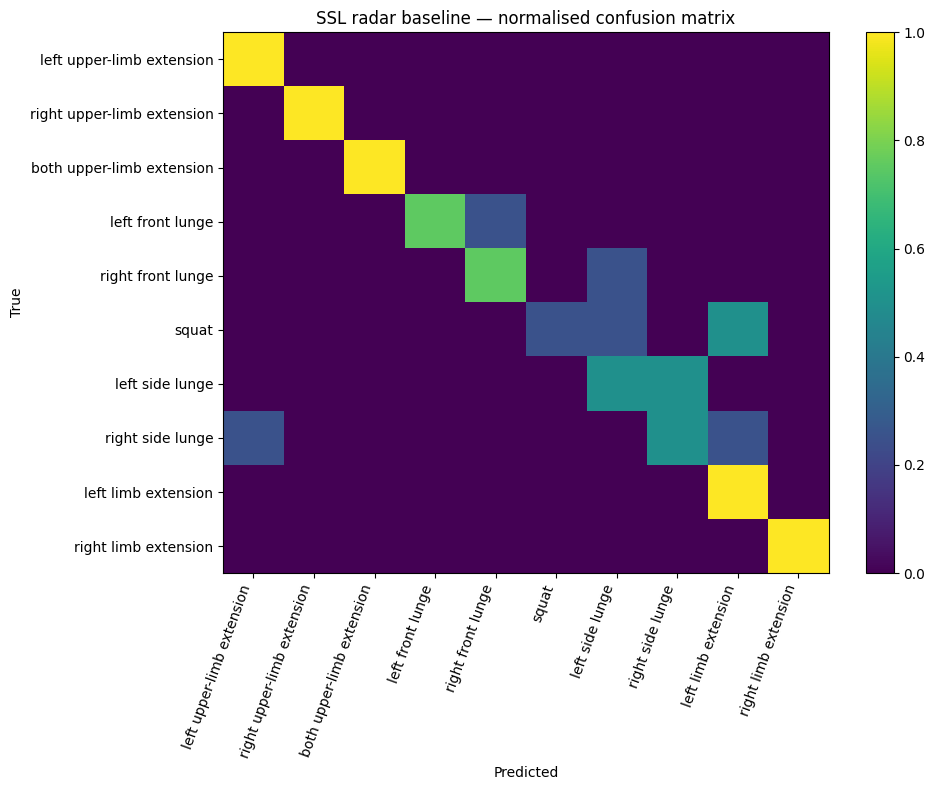


Standard KD anchor
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     1.0000    1.0000    1.0000         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     0.6667    0.5000    0.5714         4
           left side lunge     0.6667    0.5000    0.5714         4
          right side lunge     0.6000    0.7500    0.6667         4
       left limb extension     0.6000    0.7500    0.6667         4
      right limb extension     0.8000    1.0000    0.8889         4

                  accuracy                         0.8000        40
                 macro avg     0.8133    0.8000    0.7921        40
              weighted avg     0.8133    0.8000    0.7921        40



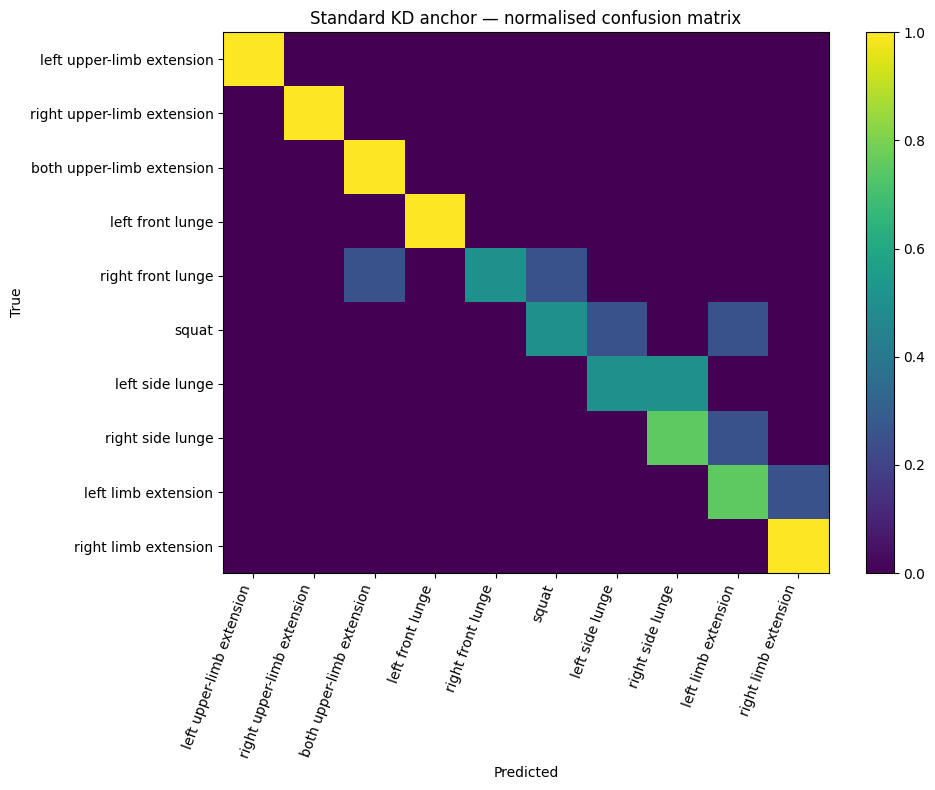


PARETO-RKD enhanced
                            precision    recall  f1-score   support

 left upper-limb extension     0.8000    1.0000    0.8889         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     0.8000    1.0000    0.8889         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     1.0000    0.2500    0.4000         4
           left side lunge     0.6667    0.5000    0.5714         4
          right side lunge     0.6667    0.5000    0.5714         4
       left limb extension     0.5000    1.0000    0.6667         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.7750        40
                 macro avg     0.8233    0.7750    0.7543        40
              weighted avg     0.8233    0.7750    0.7543        40



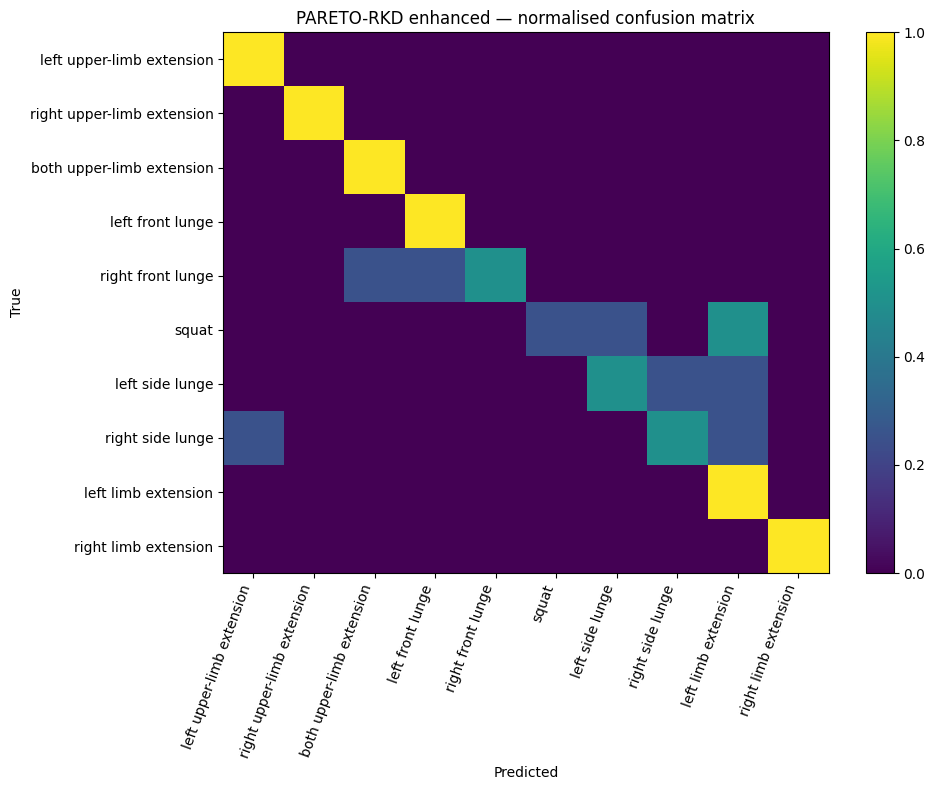


Pareto-selected radar
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     1.0000    1.0000    1.0000         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     0.6667    0.5000    0.5714         4
           left side lunge     0.6667    0.5000    0.5714         4
          right side lunge     0.6000    0.7500    0.6667         4
       left limb extension     0.6000    0.7500    0.6667         4
      right limb extension     0.8000    1.0000    0.8889         4

                  accuracy                         0.8000        40
                 macro avg     0.8133    0.8000    0.7921        40
              weighted avg     0.8133    0.8000    0.7921        40



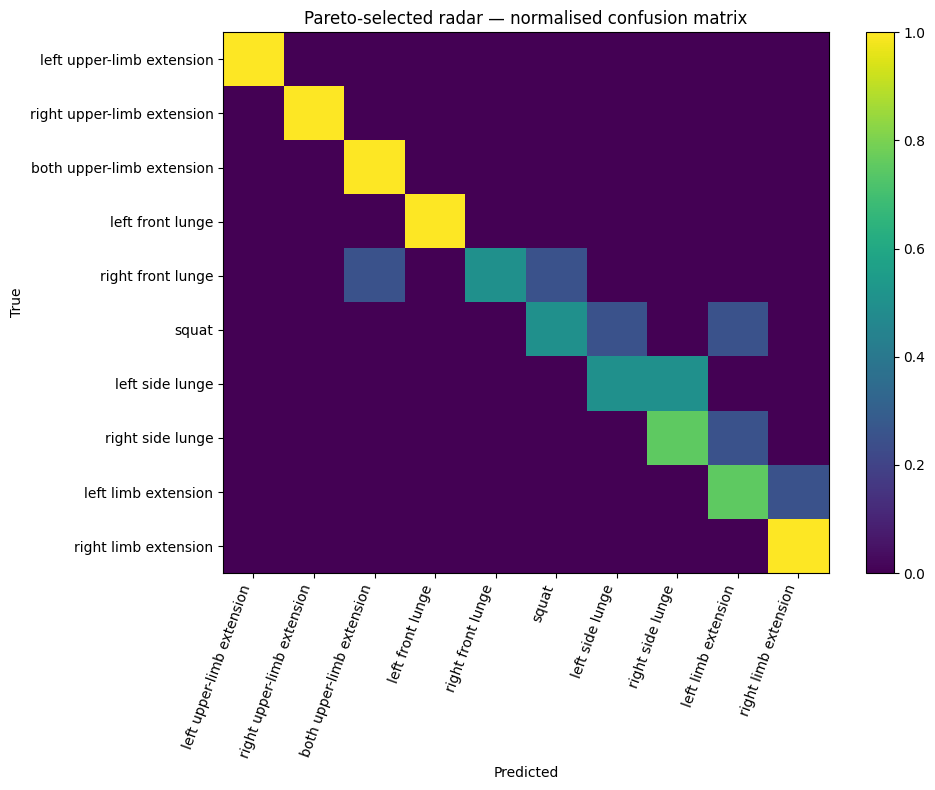

In [34]:
# ============================================================
# Classification report and confusion matrices
# ============================================================

def safe_name(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


def save_prediction_frame(name, prediction):
    frame = pd.DataFrame({
        "sample_id": prediction["sample_ids"],
        "subject": prediction["subjects"],
        "true_id": prediction["y_true"],
        "pred_id": prediction["y_pred"],
        "true_label": [
            CLASS_NAMES[index]
            for index in prediction["y_true"]
        ],
        "pred_label": [
            CLASS_NAMES[index]
            for index in prediction["y_pred"]
        ],
        "confidence": prediction["probabilities"].max(axis=1),
        "instance_temperature": prediction["temperature"],
    })

    for class_id, class_name in enumerate(CLASS_NAMES):
        frame[
            f"prob_{class_id:02d}_{safe_name(class_name)}"
        ] = prediction["probabilities"][:, class_id]

    frame.to_csv(
        Path(cfg.WORK_DIR) / f"predictions_{safe_name(name)}.csv",
        index=False,
    )
    return frame


def plot_confusion(name, prediction):
    matrix = confusion_matrix(
        prediction["y_true"],
        prediction["y_pred"],
        labels=list(range(NUM_CLASSES)),
        normalize="true",
    )
    figure, axis = plt.subplots(figsize=(10, 8))
    image = axis.imshow(matrix, vmin=0.0, vmax=1.0, aspect="auto")
    axis.set_title(f"{name} — normalised confusion matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")
    axis.set_xticks(
        range(NUM_CLASSES),
        CLASS_NAMES,
        rotation=70,
        ha="right",
    )
    axis.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    figure.savefig(
        Path(cfg.WORK_DIR) / f"confusion_{safe_name(name)}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


for name, prediction in test_predictions.items():
    print("\n" + "=" * 90)
    print(name)
    print(
        classification_report(
            prediction["y_true"],
            prediction["y_pred"],
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )
    save_prediction_frame(name, prediction)
    plot_confusion(name, prediction)

# 11. Reliability-gate sensitivity

A successful gate should show:

- increasing radar weight as IMU corruption severity rises;
- increasing IMU weight as radar corruption severity rises;
- high agreement with the lower-loss modality expert.

In [35]:
# ============================================================
# Test-set gate adaptation and oracle agreement
# ============================================================

gate_test_rows = []

for modality in ["clean", "radar", "imu"]:
    severities = [0.0] if modality == "clean" else [0.10, 0.30, 0.50, 0.70]

    for severity in severities:
        prediction = predict_teacher(
            teacher_model,
            test_loader,
            corruption=modality,
            severity=severity,
            seed=cfg.SEED + 50,
        )
        metrics = metric_dictionary(
            prediction["y_true"],
            prediction["y_pred"],
        )

        gate_test_rows.append({
            "corruption": modality,
            "severity": severity,
            **metrics,
            "radar_gate": float(prediction["mean_gate"][:, 0].mean()),
            "imu_gate": float(prediction["mean_gate"][:, 1].mean()),
            "gate_oracle_agreement": gate_oracle_agreement(prediction),
        })

gate_test_df = pd.DataFrame(gate_test_rows)
display(gate_test_df)
gate_test_df.to_csv(
    Path(cfg.WORK_DIR) / "gate_test_adaptation.csv",
    index=False,
)

clean_gate = gate_test_df[
    gate_test_df["corruption"] == "clean"
].iloc[0]

imu_curve = gate_test_df[
    gate_test_df["corruption"] == "imu"
].sort_values("severity")
radar_curve = gate_test_df[
    gate_test_df["corruption"] == "radar"
].sort_values("severity")

gate_summary = pd.DataFrame([{
    "clean_radar_gate": clean_gate["radar_gate"],
    "clean_imu_gate": clean_gate["imu_gate"],
    "radar_gate_shift_at_imu_070": (
        imu_curve.iloc[-1]["radar_gate"]
        - clean_gate["radar_gate"]
    ),
    "imu_gate_shift_at_radar_070": (
        radar_curve.iloc[-1]["imu_gate"]
        - clean_gate["imu_gate"]
    ),
    "imu_corruption_radar_gate_monotonic_fraction": float(
        np.mean(np.diff(imu_curve["radar_gate"].values) >= -1e-4)
    ),
    "radar_corruption_imu_gate_monotonic_fraction": float(
        np.mean(np.diff(radar_curve["imu_gate"].values) >= -1e-4)
    ),
}])

display(gate_summary)
gate_summary.to_csv(
    Path(cfg.WORK_DIR) / "gate_adaptation_summary.csv",
    index=False,
)

,corruption,severity,accuracy,balanced_accuracy,macro_f1,weighted_f1,radar_gate,imu_gate,gate_oracle_agreement
0,clean,0.0,0.900,0.900,0.897222,0.897222,0.229668,0.770332,0.850
1,radar,0.1,0.900,0.900,0.891111,0.891111,0.224552,0.775448,0.850
2,radar,0.3,0.875,0.875,0.873095,0.873095,0.224850,0.775150,0.900
3,radar,0.5,0.800,0.800,0.796378,0.796378,0.207441,0.792559,0.925
4,radar,0.7,0.750,0.750,0.761905,0.761905,0.206833,0.793167,1.000
5,imu,0.1,0.800,0.800,0.774394,0.774394,0.230574,0.769426,0.750
6,imu,0.3,0.800,0.800,0.796190,0.796190,0.232977,0.767023,0.775
7,imu,0.5,0.750,0.750,0.733997,0.733997,0.233143,0.766857,0.675
8,imu,0.7,0.675,0.675,0.668681,0.668681,0.237434,0.762566,0.650


,clean_radar_gate,clean_imu_gate,radar_gate_shift_at_imu_070,imu_gate_shift_at_radar_070,imu_corruption_radar_gate_monotonic_fraction,radar_corruption_imu_gate_monotonic_fraction
0,0.229668,0.770332,0.007766,0.022835,1.0,0.666667


# 12. Radar-corruption robustness

The selected model is compared against standard KD and the unselected enhanced model under identical deterministic corruptions.

In [36]:
# ============================================================
# Radar robustness benchmark
# ============================================================

ROBUSTNESS_CONDITIONS = [
    ("clean", None),
    ("frame_mask_10", ("frame_mask", 0.10)),
    ("frame_mask_30", ("frame_mask", 0.30)),
    ("frame_mask_50", ("frame_mask", 0.50)),
    ("temporal_block_30", ("temporal_block", 0.30)),
    ("channel_drop_20", ("channel_drop", 0.20)),
    ("channel_drop_40", ("channel_drop", 0.40)),
    ("gaussian_25", ("gaussian", 0.25)),
    ("gaussian_50", ("gaussian", 0.50)),
    ("spatial_mask_30", ("spatial_mask", 0.30)),
    ("amplitude_50", ("amplitude", 0.50)),
]

robustness_rows = []

if cfg.RUN_ROBUSTNESS:
    robustness_models = {
        "Standard KD anchor": (
            anchor_model,
            validation_temperatures["Standard KD anchor"],
        ),
        "PARETO-RKD enhanced": (
            enhanced_model,
            validation_temperatures["PARETO-RKD enhanced"],
        ),
        "Pareto-selected radar": (
            selected_model,
            selected_scalar_temperature,
        ),
    }

    for model_name, (model, temperature) in robustness_models.items():
        for condition_index, (condition_name, corruption) in enumerate(
            ROBUSTNESS_CONDITIONS
        ):
            prediction = predict_student(
                model,
                test_loader,
                scalar_temperature=temperature,
                corruption=corruption,
                seed=cfg.SEED + condition_index + 100,
            )
            metrics = metric_dictionary(
                prediction["y_true"],
                prediction["y_pred"],
            )
            robustness_rows.append({
                "model": model_name,
                "condition": condition_name,
                **metrics,
                "ece": expected_calibration_error(
                    prediction["probabilities"],
                    prediction["y_true"],
                )[0],
            })

    robustness_df = pd.DataFrame(robustness_rows)
    display(
        robustness_df.pivot(
            index="condition",
            columns="model",
            values="macro_f1",
        )
    )

    clean_scores = (
        robustness_df[
            robustness_df["condition"] == "clean"
        ][["model", "macro_f1"]]
        .rename(columns={"macro_f1": "clean_macro_f1"})
    )
    corrupted_summary = (
        robustness_df[
            robustness_df["condition"] != "clean"
        ]
        .groupby("model")
        .agg(
            mean_corrupt_macro_f1=("macro_f1", "mean"),
            worst_corrupt_macro_f1=("macro_f1", "min"),
            mean_corrupt_ece=("ece", "mean"),
        )
        .reset_index()
        .merge(clean_scores, on="model")
    )
    corrupted_summary["relative_robustness"] = (
        corrupted_summary["mean_corrupt_macro_f1"]
        / corrupted_summary["clean_macro_f1"].clip(lower=1e-8)
    )

    display(corrupted_summary)
    robustness_df.to_csv(
        Path(cfg.WORK_DIR) / "radar_robustness_full.csv",
        index=False,
    )
    corrupted_summary.to_csv(
        Path(cfg.WORK_DIR) / "radar_robustness_summary.csv",
        index=False,
    )
else:
    print("Robustness disabled.")

model,PARETO-RKD enhanced,Pareto-selected radar,Standard KD anchor
condition,,,
amplitude_50,0.694487,0.269630,0.269630
channel_drop_20,0.705022,0.594554,0.594554
channel_drop_40,0.673651,0.467937,0.467937
clean,0.754286,0.792063,0.792063
frame_mask_10,0.753203,0.815476,0.815476
frame_mask_30,0.744396,0.733968,0.733968
frame_mask_50,0.712489,0.361153,0.361153
gaussian_25,0.792569,0.804149,0.804149
gaussian_50,0.753997,0.632773,0.632773


,model,mean_corrupt_macro_f1,worst_corrupt_macro_f1,mean_corrupt_ece,clean_macro_f1,relative_robustness
0,PARETO-RKD enhanced,0.722931,0.644069,0.153874,0.754286,0.958431
1,Pareto-selected radar,0.594594,0.269630,0.176351,0.792063,0.750690
2,Standard KD anchor,0.594594,0.269630,0.176351,0.792063,0.750690


# 13. Conformal prediction

Validation probabilities define a split-conformal threshold. The test report includes empirical coverage and average prediction-set size. This supplements—not replaces—probability calibration.

In [37]:
# ============================================================
# Split-conformal prediction sets
# ============================================================

def conformal_quantile(validation_probabilities, validation_labels, alpha):
    conformity = validation_probabilities[
        np.arange(len(validation_labels)),
        validation_labels,
    ]
    nonconformity = 1.0 - conformity
    level = min(
        1.0,
        math.ceil((len(nonconformity) + 1) * (1.0 - alpha))
        / len(nonconformity),
    )
    return float(np.quantile(nonconformity, level, method="higher"))


def conformal_set_metrics(probabilities, labels, quantile):
    included = (1.0 - probabilities) <= quantile
    coverage = included[
        np.arange(len(labels)),
        labels,
    ].mean()
    set_size = included.sum(axis=1)
    return {
        "coverage": float(coverage),
        "mean_set_size": float(set_size.mean()),
        "median_set_size": float(np.median(set_size)),
        "singleton_fraction": float((set_size == 1).mean()),
        "empty_fraction": float((set_size == 0).mean()),
    }, included


selected_validation_prediction = predict_student(
    selected_model,
    val_loader,
    scalar_temperature=selected_scalar_temperature,
)
conformal_q = conformal_quantile(
    selected_validation_prediction["probabilities"],
    selected_validation_prediction["y_true"],
    cfg.CONFORMAL_ALPHA,
)

conformal_metrics, conformal_sets = conformal_set_metrics(
    selected_prediction["probabilities"],
    selected_prediction["y_true"],
    conformal_q,
)

conformal_df = pd.DataFrame([{
    "alpha": cfg.CONFORMAL_ALPHA,
    "quantile": conformal_q,
    **conformal_metrics,
}])

display(conformal_df)
conformal_df.to_csv(
    Path(cfg.WORK_DIR) / "conformal_test_results.csv",
    index=False,
)

,alpha,quantile,coverage,mean_set_size,median_set_size,singleton_fraction,empty_fraction
0,0.1,0.973579,0.975,2.725,2.0,0.225,0.0


# 14. Fair ablation study

Every variant uses:

- the same teacher;
- the same student initialisation;
- the same epoch budget;
- the same train/validation/test split.

This corrects the unequal-budget concern in the previous ablation.

In [40]:
# ============================================================
# Optional fair ablations
# ============================================================

ablation_results = pd.DataFrame()

if cfg.RUN_ABLATIONS:
    variants = [
        EnhancedOptions(
            use_robustness=False,
            use_calibration=False,
            use_temporal=False,
            use_relation=False,
            use_prototype=False,
            name="adaptive_logit_kd_only",
        ),
        EnhancedOptions(
            use_robustness=True,
            use_calibration=False,
            use_temporal=False,
            use_relation=False,
            use_prototype=False,
            name="plus_worst_view_robustness",
        ),
        EnhancedOptions(
            use_robustness=True,
            use_calibration=True,
            use_temporal=False,
            use_relation=False,
            use_prototype=False,
            name="plus_instance_calibration",
        ),
        EnhancedOptions(
            use_robustness=True,
            use_calibration=True,
            use_temporal=True,
            use_relation=False,
            use_prototype=False,
            name="plus_routed_temporal",
        ),
        EnhancedOptions(
            use_robustness=True,
            use_calibration=True,
            use_temporal=True,
            use_relation=True,
            use_prototype=False,
            name="plus_routed_relation",
        ),
        EnhancedOptions(
            use_robustness=True,
            use_calibration=True,
            use_temporal=True,
            use_relation=True,
            use_prototype=True,
            name="full_pareto_rkd",
        ),
    ]

    rows = []

    for variant in variants:
        print("\n" + "=" * 100)
        print("ABLATION:", variant.name)

        model = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
        model.load_state_dict(common_initial_state)

        history = train_pareto_student(
            model,
            teacher_model,
            teacher_prototypes,
            train_loader,
            val_loader,
            train_df,
            cfg.ABLATION_EPOCHS,
            variant,
        )
        history.to_csv(
            Path(cfg.WORK_DIR)
            / f"ablation_history_{variant.name}.csv",
            index=False,
        )

        temperature = fit_student_scalar_temperature(model, val_loader)
        prediction = predict_student(
            model,
            test_loader,
            scalar_temperature=temperature,
        )
        row, _ = calibrated_metric_row(
            variant.name,
            prediction,
            scalar_temperature=1.0,
        )
        rows.append(row)

        torch.save(
            model.state_dict(),
            Path(cfg.WORK_DIR) / f"ablation_{variant.name}.pt",
        )

        del model
        gc.collect()
        torch.cuda.empty_cache()

    ablation_results = (
        pd.DataFrame(rows)
        .set_index("model")
        .sort_values("macro_f1", ascending=False)
    )
    display(ablation_results.style.format("{:.4f}"))
    ablation_results.to_csv(
        Path(cfg.WORK_DIR) / "fair_ablation_results.csv"
    )
else:
    print("Ablations disabled. Set cfg.RUN_ABLATIONS=True after the primary run.")


ABLATION: adaptive_logit_kd_only
adaptive_logit_kd_only 01/18 | loss=3.9188 | robust=0.0000 | T=1.000 | val_macro_f1=0.4579
adaptive_logit_kd_only 02/18 | loss=2.7764 | robust=0.0000 | T=1.000 | val_macro_f1=0.4932
adaptive_logit_kd_only 03/18 | loss=2.3809 | robust=0.0000 | T=1.000 | val_macro_f1=0.4339
adaptive_logit_kd_only 04/18 | loss=2.0200 | robust=0.0000 | T=1.000 | val_macro_f1=0.6551
adaptive_logit_kd_only 05/18 | loss=1.8614 | robust=0.0000 | T=1.000 | val_macro_f1=0.5037
adaptive_logit_kd_only 06/18 | loss=1.7567 | robust=0.0000 | T=1.000 | val_macro_f1=0.5789
adaptive_logit_kd_only 07/18 | loss=1.4612 | robust=0.0000 | T=1.000 | val_macro_f1=0.6643
adaptive_logit_kd_only 08/18 | loss=1.3973 | robust=0.0000 | T=1.000 | val_macro_f1=0.6660
adaptive_logit_kd_only 09/18 | loss=1.1801 | robust=0.0000 | T=1.000 | val_macro_f1=0.6995
adaptive_logit_kd_only 10/18 | loss=1.2309 | robust=0.0000 | T=1.000 | val_macro_f1=0.6557
adaptive_logit_kd_only 11/18 | loss=1.1036 | robust=0.00

,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,scalar_temperature
model,,,,,,,,
adaptive_logit_kd_only,0.8250,0.8250,0.8257,0.8257,0.6860,0.2687,0.1294,1.0000
plus_routed_temporal,0.8250,0.8250,0.8073,0.8073,0.8424,0.3275,0.1056,1.0000
plus_worst_view_robustness,0.8000,0.8000,0.7937,0.7937,0.6264,0.2677,0.1364,1.0000
plus_routed_relation,0.7750,0.7750,0.7603,0.7603,0.8145,0.3250,0.1204,1.0000
full_pareto_rkd,0.7500,0.7500,0.7357,0.7357,0.8545,0.3562,0.1045,1.0000
plus_instance_calibration,0.7500,0.7500,0.7340,0.7340,0.9259,0.3832,0.1858,1.0000


# 15. Optional grouped subject folds

The primary claim should be based on grouped subject folds, not one split. This section prepares leakage-free folds and reruns a reduced version of the complete method. It is disabled by default because it is computationally expensive.

In [44]:
# ============================================================
# Optional five-fold subject evaluation
# ============================================================

def build_loaders_for_subject_split(
    train_subject_list,
    validation_subject_list,
    test_subject_list,
):
    split_stats = compute_training_stats(train_subject_list)

    local_train = manifest[
        manifest["subject"].isin(train_subject_list)
    ].reset_index(drop=True)
    local_validation = manifest[
        manifest["subject"].isin(validation_subject_list)
    ].reset_index(drop=True)
    local_test = manifest[
        manifest["subject"].isin(test_subject_list)
    ].reset_index(drop=True)

    datasets = {
        "train": MRISegmentDataset(
            local_train,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "validation": MRISegmentDataset(
            local_validation,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "test": MRISegmentDataset(
            local_test,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
    }

    loader_arguments = dict(
        batch_size=cfg.BATCH_SIZE,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=cfg.NUM_WORKERS > 0,
    )

    loaders = {
        "train": DataLoader(
            datasets["train"],
            shuffle=True,
            drop_last=False,
            **loader_arguments,
        ),
        "validation": DataLoader(
            datasets["validation"],
            shuffle=False,
            **loader_arguments,
        ),
        "test": DataLoader(
            datasets["test"],
            shuffle=False,
            **loader_arguments,
        ),
    }

    return local_train, local_validation, local_test, loaders


def grouped_subject_partitions(subjects, folds, seed):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(np.asarray(sorted(subjects)))
    return [np.asarray(group) for group in np.array_split(shuffled, folds)]


grouped_cv_results = pd.DataFrame()

if cfg.RUN_GROUPED_CV:
    groups = grouped_subject_partitions(
        manifest["subject"].unique(),
        cfg.CV_FOLDS,
        cfg.SEED,
    )
    rows = []

    for fold_index in range(cfg.CV_FOLDS):
        print("\n" + "#" * 100)
        print(f"FOLD {fold_index + 1}/{cfg.CV_FOLDS}")

        fold_test_subjects = groups[fold_index]
        fold_validation_subjects = groups[
            (fold_index + 1) % cfg.CV_FOLDS
        ]
        fold_train_subjects = np.concatenate([
            groups[index]
            for index in range(cfg.CV_FOLDS)
            if index not in {
                fold_index,
                (fold_index + 1) % cfg.CV_FOLDS,
            }
        ])

        (
            fold_train_df,
            fold_validation_df,
            fold_test_df,
            fold_loaders,
        ) = build_loaders_for_subject_split(
            fold_train_subjects,
            fold_validation_subjects,
            fold_test_subjects,
        )

        fold_teacher = CounterfactualReliabilityTeacher(
            NUM_CLASSES
        ).to(DEVICE)
        train_counterfactual_teacher(
            fold_teacher,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
        )

        fold_prototypes = compute_confidence_filtered_prototypes(
            fold_teacher,
            fold_loaders["train"],
        ).to(DEVICE)

        fold_initial = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
        fold_initial.encoder.load_state_dict(
            fold_teacher.radar_encoder.state_dict(),
            strict=True,
        )
        fold_initial_state = copy.deepcopy(fold_initial.state_dict())

        fold_anchor = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
        fold_anchor.load_state_dict(fold_initial_state)
        train_standard_kd(
            fold_anchor,
            fold_teacher,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
            name=f"fold_{fold_index + 1}_anchor",
        )

        fold_enhanced = CalibratedRadarStudent(NUM_CLASSES).to(DEVICE)
        fold_enhanced.load_state_dict(fold_initial_state)
        train_pareto_student(
            fold_enhanced,
            fold_teacher,
            fold_prototypes,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
            full_options,
        )

        for model_name, model in [
            ("anchor", fold_anchor),
            ("enhanced", fold_enhanced),
        ]:
            temperature = fit_student_scalar_temperature(
                model,
                fold_loaders["validation"],
            )
            prediction = predict_student(
                model,
                fold_loaders["test"],
                scalar_temperature=temperature,
            )
            rows.append({
                "fold": fold_index + 1,
                "model": model_name,
                **metric_dictionary(
                    prediction["y_true"],
                    prediction["y_pred"],
                ),
                "ece": expected_calibration_error(
                    prediction["probabilities"],
                    prediction["y_true"],
                )[0],
                "train_subjects": "|".join(
                    sorted(fold_train_subjects.tolist())
                ),
                "validation_subjects": "|".join(
                    sorted(fold_validation_subjects.tolist())
                ),
                "test_subjects": "|".join(
                    sorted(fold_test_subjects.tolist())
                ),
            })

        del (
            fold_teacher,
            fold_prototypes,
            fold_initial,
            fold_anchor,
            fold_enhanced,
        )
        gc.collect()
        torch.cuda.empty_cache()

    grouped_cv_results = pd.DataFrame(rows)
    grouped_cv_summary = (
        grouped_cv_results
        .groupby("model")[
            [
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
                "ece",
            ]
        ]
        .agg(["mean", "std"])
    )

    display(grouped_cv_results)
    display(grouped_cv_summary)

    grouped_cv_results.to_csv(
        Path(cfg.WORK_DIR) / "grouped_cv_results.csv",
        index=False,
    )
    grouped_cv_summary.to_csv(
        Path(cfg.WORK_DIR) / "grouped_cv_summary.csv"
    )
else:
    print("Grouped CV disabled. Enable only after the primary experiment succeeds.")


####################################################################################################
FOLD 1/5
teacher 01/8 | loss=4.1228 | gate=0.1902 | rank=0.0802 | severity=0.080 | val_macro_f1=0.1897
teacher 02/8 | loss=2.4894 | gate=0.1589 | rank=0.0801 | severity=0.304 | val_macro_f1=0.4287
teacher 03/8 | loss=1.6928 | gate=0.1318 | rank=0.0808 | severity=0.528 | val_macro_f1=0.7836
teacher 04/8 | loss=1.1744 | gate=0.1147 | rank=0.0799 | severity=0.550 | val_macro_f1=0.8163
teacher 05/8 | loss=0.9781 | gate=0.0911 | rank=0.0796 | severity=0.550 | val_macro_f1=0.8061
teacher 06/8 | loss=1.0171 | gate=0.1062 | rank=0.0783 | severity=0.550 | val_macro_f1=0.8721
teacher 07/8 | loss=0.8785 | gate=0.1009 | rank=0.0767 | severity=0.550 | val_macro_f1=0.8290
teacher 08/8 | loss=0.7723 | gate=0.0755 | rank=0.0760 | severity=0.550 | val_macro_f1=0.8172
fold_1_anchor 01/8 | loss=4.0011 | val_macro_f1=0.1840
fold_1_anchor 02/8 | loss=2.9236 | val_macro_f1=0.4622
fold_1_anchor 03/8 | loss=2

,fold,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,ece,train_subjects,validation_subjects,test_subjects
0,1,anchor,0.675,0.675,0.635556,0.635556,0.165040,subject03|subject04|subject05|subject06|subjec...,subject02|subject07|subject14|subject16,subject01|subject10|subject15|subject19
1,1,enhanced,0.700,0.700,0.635426,0.635426,0.162849,subject03|subject04|subject05|subject06|subjec...,subject02|subject07|subject14|subject16,subject01|subject10|subject15|subject19
2,2,anchor,0.675,0.675,0.653189,0.653189,0.149811,subject01|subject04|subject05|subject06|subjec...,subject03|subject09|subject12|subject13,subject02|subject07|subject14|subject16
3,2,enhanced,0.725,0.725,0.715122,0.715122,0.050339,subject01|subject04|subject05|subject06|subjec...,subject03|subject09|subject12|subject13,subject02|subject07|subject14|subject16
4,3,anchor,0.750,0.750,0.740932,0.740932,0.253725,subject01|subject02|subject05|subject07|subjec...,subject04|subject06|subject17|subject18,subject03|subject09|subject12|subject13
5,3,enhanced,0.675,0.675,0.671429,0.671429,0.156246,subject01|subject02|subject05|subject07|subjec...,subject04|subject06|subject17|subject18,subject03|subject09|subject12|subject13
6,4,anchor,0.575,0.575,0.538442,0.538442,0.191717,subject01|subject02|subject03|subject07|subjec...,subject05|subject08|subject11|subject20,subject04|subject06|subject17|subject18
7,4,enhanced,0.750,0.750,0.743442,0.743442,0.195011,subject01|subject02|subject03|subject07|subjec...,subject05|subject08|subject11|subject20,subject04|subject06|subject17|subject18
8,5,anchor,0.625,0.625,0.574444,0.574444,0.146907,subject02|subject03|subject04|subject06|subjec...,subject01|subject10|subject15|subject19,subject05|subject08|subject11|subject20
9,5,enhanced,0.700,0.700,0.652218,0.652218,0.159350,subject02|subject03|subject04|subject06|subjec...,subject01|subject10|subject15|subject19,subject05|subject08|subject11|subject20


accuracy           balanced_accuracy            macro_f1            \
             mean       std              mean       std      mean       std   
model                                                                         
anchor       0.66  0.065192              0.66  0.065192  0.628513  0.077995   
enhanced     0.71  0.028504              0.71  0.028504  0.683527  0.044801   

         weighted_f1                 ece            
                mean       std      mean       std  
model                                               
anchor      0.628513  0.077995  0.181440  0.044138  
enhanced    0.683527  0.044801  0.144759  0.055028

In [45]:
# ============================================================
# Save complete experiment package
# ============================================================

summary = {
    "method": (
        "PARETO-RKD: Pareto-Safe Adaptive Reliability, "
        "Calibration and Corruption-Robust Knowledge Distillation"
    ),
    "configuration": asdict(cfg),
    "data_root": str(DATA_ROOT),
    "num_subjects": int(manifest["subject"].nunique()),
    "num_segments": int(len(manifest)),
    "train_subjects": sorted(train_subjects.tolist()),
    "validation_subjects": sorted(val_subjects.tolist()),
    "test_subjects": sorted(test_subjects.tolist()),
    "selected_alpha": selected_alpha,
    "selected_scalar_temperature": selected_scalar_temperature,
    "main_results": results_df.reset_index().to_dict("records"),
    "bootstrap": bootstrap_df.to_dict("records"),
    "gate_summary": gate_summary.to_dict("records"),
    "conformal": conformal_df.to_dict("records"),
    "ablation_enabled": cfg.RUN_ABLATIONS,
    "grouped_cv_enabled": cfg.RUN_GROUPED_CV,
}

with open(
    Path(cfg.WORK_DIR) / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(summary, handle, indent=2)

archive_path = shutil.make_archive(
    str(Path("/kaggle/working") / "pareto_rkd_mri_outputs"),
    "zip",
    cfg.WORK_DIR,
)

print("Output directory:", cfg.WORK_DIR)
print("Archive:", archive_path)
display(results_df.style.format("{:.4f}"))

Output directory: /kaggle/working/pareto_rkd_mri
Archive: /kaggle/working/pareto_rkd_mri_outputs.zip


,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,scalar_temperature
model,,,,,,,,
Counterfactual teacher,0.9000,0.9000,0.8972,0.8972,0.3180,0.1800,0.0863,0.6547
Pareto-selected radar,0.8000,0.8000,0.7921,0.7921,0.6389,0.2580,0.1580,1.0626
Standard KD anchor,0.8000,0.8000,0.7921,0.7921,0.6389,0.2580,0.1580,1.0626
SSL radar baseline,0.7750,0.7750,0.7623,0.7623,0.7228,0.3180,0.1618,1.0036
PARETO-RKD enhanced,0.7750,0.7750,0.7543,0.7543,0.8457,0.3181,0.1729,0.9728


# Interpretation and claim checklist

A strong result requires all of the following:

1. **Accuracy/F1:** the Pareto-selected radar model exceeds standard KD on test macro-F1 and accuracy.
2. **Adaptive gate:** radar weight rises monotonically as IMU corruption increases, and IMU weight rises as radar corruption increases.
3. **Calibration:** selected-model ECE, NLL and Brier are lower than or comparable with standard KD.
4. **Radar robustness:** selected-model mean and worst corruption macro-F1 exceed standard KD.
5. **Safe auxiliaries:** routed temporal/relation/prototype weights are often non-zero but are suppressed when gradient conflict occurs.
6. **Ablation:** the fair equal-budget ablation shows that robustness, calibration and routed auxiliaries add complementary value.
7. **Generalisation:** grouped-subject folds show a positive average student improvement with reduced variance.

### Defensible novelty statement

> We propose PARETO-RKD, a radar-only deployment framework that learns a counterfactually supervised radar–IMU reliability teacher, trains a calibration-aware student against worst-case radar views, admits structural distillation losses only under positive gradient agreement, and uses validation-only Pareto-safe checkpoint fusion to prevent auxiliary objectives from replacing a stronger standard-KD solution.

The work remains an exercise-recognition feasibility study. It should not be described as a clinical diagnostic or treatment-assessment system.